<table width="100%" style="border:none; border-collapse:collapse;">
<tr style="border:none;">
<td width="150" style="border:none;"></td>
<td align="center" style="border:none;">
    <h1>Tarea Semanal 2</h1>
    <h2>Teoría de los Circuitos II - R4052</h2>
    <h3>Fabián Alexander Iturrizaga Meza</h3>
    <br>
    <b>Docentes</b><br>
    Profesor: Mariano Llamedo Soria<br>
    Jefe de TPs: César Fuoco<br>
    Ayudante de TPs: David Moharos
</td>
<td width="150" align="right" style="border:none; vertical-align:top;"><img src="./img/logo_UTN.svg" width="150" /></td>
</tr>
</table>

***

## Consigna

<img src="./img/consigna.png" width="800" />

***

## Índice

> **Nota:** los hipervínculos funcionan correctamente en JupyterLab y VS Code abiertos localmente. Si el notebook se visualiza desde **GitHub** o **NBViewer**, los links pueden no redirigir (GitHub no soporta anclas internas de Jupyter).

1. [Punto 1 — Función transferencia Butterworth de orden 6](#p1)
2. [Punto 2 — Módulo, fase y polos/ceros](#p2)
3. [Punto 3 — Red normalizada con SOS (Sallen-Key, KHN, MFB)](#p3)
4. [Punto 4 — Normas y ajuste de ganancia de +10 dB](#p4)
5. Punto 5 — Verificación con Python y LTSpice

   > **Aclaración:** todas las verificaciones en Python y LTSpice se realizaron integradas dentro del punto correspondiente (Puntos 3, 4 y Bonus), a continuación de cada desarrollo teórico. No existe una sección separada de "Punto 5".

**Bonus:**
- [Bonus 1 — ¿Se pueden reutilizar las SOS del $n=6$ para el $n=7$?](#b1)
- [Bonus 2 — Diseño de la cascada Butterworth $n=7$](#b2)
- [Bonus 3 — Verificación en LTSpice del Butterworth $n=7$](#b3)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import sympy as sp
from scipy import signal as sig
import matplotlib.pyplot as plt

# PyTC2: librería para Teoría de Circuitos II
from pytc2.sistemas_lineales import bodePlot, pzmap, analyze_sys
from pytc2.general import print_subtitle, print_latex, a_equal_b_latex_s

# Configuración de gráficos
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams['figure.dpi'] = 150
plt.rcParams.update({'font.size': 11})

# ─── Variable de Laplace y helpers simbólicos compartidos ───
s = sp.Symbol('s', complex=True)

def normalize(T):
    """Divide num y den por el coef de s² del denominador (forma mónica)."""
    num, den = sp.fraction(sp.cancel(T))
    den_exp  = sp.expand(den)
    a2 = den_exp.coeff(s, 2)
    a1 = den_exp.coeff(s, 1)
    a0 = den_exp.coeff(s, 0)
    num_n = sp.simplify(sp.expand(num) / a2)
    den_n = s**2 + sp.simplify(a1/a2)*s + sp.simplify(a0/a2)
    return num_n / den_n

def neat(e):
    """Recombina raíces sueltas: sqrt(a)·sqrt(b) → sqrt(a·b).
    Truco: reemplaza símbolos positivos por dummies sin assumptions
    (mismo nombre) para que SymPy no auto-distribuya el sqrt."""
    pos_syms = [s for s in e.free_symbols if s.is_positive]
    dummies  = {s: sp.Symbol(s.name) for s in pos_syms}
    return sp.powsimp(e.xreplace(dummies), force=True, combine='base')

def extract_biquad_params(T, filter_type):
    """Extrae (K, ω₀, Q) de una transferencia biquadrática.
    filter_type ∈ {'LPF', 'HPF', 'BPF'}."""
    num, den = sp.fraction(sp.cancel(T))
    num_exp  = sp.expand(num)
    den_exp  = sp.expand(den)
    a2, a1, a0 = den_exp.coeff(s, 2), den_exp.coeff(s, 1), den_exp.coeff(s, 0)
    n2, n1, n0 = num_exp.coeff(s, 2), num_exp.coeff(s, 1), num_exp.coeff(s, 0)
    w0sq = sp.simplify(a0/a2)
    w0Q  = sp.simplify(a1/a2)
    w0   = sp.sqrt(w0sq)
    Q    = sp.simplify(w0 / w0Q)
    if   filter_type == 'LPF': K = sp.simplify(n0/a0)         # T(0) = K
    elif filter_type == 'HPF': K = sp.simplify(n2/a2)         # coef de s² del numerador
    elif filter_type == 'BPF': K = sp.simplify(n1/a1)         # coef de s normalizado
    return neat(K), neat(w0), neat(Q)


<a id="p1"></a>

***

## Punto 1 — Función transferencia Butterworth de orden 6

### Resolución manuscrita

Originales: `p1_hoja_1.jpg` a `p1_hoja_4.jpg` en [img/](./img/)

<img src="./img/p1_hoja_1.jpg" width="450" />

<img src="./img/p1_hoja_2.jpg" width="450" />

<img src="./img/p1_hoja_3.jpg" width="450" />

<img src="./img/p1_hoja_4.jpg" width="450" />

### Desarrollo analítico

#### 1) Módulo cuadrado de la aproximación de Butterworth

Partimos de la función de aproximación cuadrática normalizada con $\varepsilon^2 = 1$ (Butterworth):

$$
|T(j\omega)|^2 = \frac{1}{1 + \omega^{2n}} = T(j\omega) \cdot T^*(j\omega) \quad \mathbf{(1)}
$$

---

#### 2) Extensión analítica a $s$ complejo

Realizando el cambio de variable $s = j\omega \Rightarrow \omega = s/j$, y usando $T^*(j\omega) = T(-s)$:

$$
T(s) \cdot T(-s) = \frac{1}{1 + \left(\frac{s}{j}\right)^{2n}} = \frac{1}{1 + \frac{s^{2n}}{j^{2n}}} \quad \mathbf{(2)}
$$

Dado que $j^{2n} = (j^2)^n = (-1)^n$, para $n$ **par** se tiene $(-1)^n = 1$:

$$
\boxed{T(s) \cdot T(-s) = \frac{1}{1 + s^{2n}}} \quad \mathbf{(3)}
$$

---

#### 3) Ubicación de los polos

Los $2n$ polos de $\mathbf{(3)}$ satisfacen $s^{2n} = -1 = e^{j\pi(2k+1)}$, de donde:

$$
\phi_k = \frac{k\pi}{n} + \frac{\pi}{2n}, \qquad k = 0, 1, \ldots, 2n-1 \quad \mathbf{(4)}
$$

Los polos están distribuidos sobre el **círculo unitario**, el primero a $\phi_0 = \pi/(2n)$ del eje $\sigma$, con separación angular $\Delta\phi = \pi/n$. Para construir $T(s)$ se seleccionan los $n$ polos del semiplano izquierdo (SPI).

---

#### 4) Aplicación para $n = 6$

Con $n = 6$: $\phi_0 = \pi/12$ y $\Delta\phi = \pi/6$. Los ángulos de los tres pares conjugados del SPI son:

$$
\phi_0 = \frac{\pi}{12} \quad (15°), \qquad
\phi_1 = \frac{\pi}{4} \quad (45°), \qquad
\phi_2 = \frac{5\pi}{12} \quad (75°) \quad \mathbf{(5)}
$$

con los polos del SPI (ángulo medido desde el eje $\sigma$):

$$
P_{k_{1,2}} = -\cos(\phi_k) \pm j\sin(\phi_k), \qquad k = 0, 1, 2 \quad \mathbf{(6)}
$$

> $Q_2 > Q_1 > Q_0$: el par más cercano al eje $j\omega$ (ángulo más grande) tiene el mayor $Q$.

---

#### 5) Factores de segundo orden

Para cada par conjugado, con $a = s + \cos\phi_k$ y $b = \sin\phi_k$:

$$
(s - P_{k_1})(s - P_{k_2})
= (a - jb)(a + jb)
= a^2 + b^2
= (s + \cos\phi_k)^2 + \sin^2\phi_k
= s^2 + 2\cos(\phi_k)\,s + \underbrace{\cos^2\phi_k + \sin^2\phi_k}_{=\,1}
$$

$$
\boxed{(s - P_{k_1})(s - P_{k_2}) = s^2 + 2\cos(\phi_k)\,s + 1} \quad \mathbf{(7)}
$$

---

#### 6) Transferencia de Butterworth de orden 6

Aplicando $\mathbf{(7)}$ a los tres ángulos de $\mathbf{(5)}$:

$$
\boxed{T_{\text{Butter}}(s) = \frac{1}{\Bigl(s^2 + 2\cos\tfrac{\pi}{12}\,s + 1\Bigr)\,\Bigl(s^2 + 2\cos\tfrac{\pi}{4}\,s + 1\Bigr)\,\Bigl(s^2 + 2\cos\tfrac{5\pi}{12}\,s + 1\Bigr)}} \quad \mathbf{(8)}
$$

El denominador expandido y el diagrama de polos se obtienen numéricamente a continuación.

In [2]:
# Construcción de T_Butter(s) desde los factores cuadráticos derivados analíticamente
# Cada SOS: s² + 2·cos(φ_k)·s + 1, con φ_k = π/12, π/4, 5π/12
phi = np.array([np.pi/12, np.pi/4, 5*np.pi/12])
phi_labels = ['π/12', 'π/4', '5π/12']

den_b6 = np.array([1.0])
for p in phi:
    den_b6 = np.polymul(den_b6, [1.0, 2*np.cos(p), 1.0])

H_b6 = sig.TransferFunction([1.0], den_b6)

print_subtitle('Factores cuadráticos — Butterworth n = 6')
print(f'\n  {"k":>2}  {"φ_k":>8}  {"2·cos(φ_k)":>12}  {"Q_k = 1/(2cosφ)":>18}')
print('  ' + '-'*48)
for k, (p, lbl) in enumerate(zip(phi, phi_labels)):
    print(f'  {k:>2}  {lbl:>8}  {2*np.cos(p):>12.4f}  {1/(2*np.cos(p)):>18.4f}')

print_subtitle('Denominador expandido D(s)')
print(f'  {np.round(den_b6, 4)}')

print_subtitle('Polos de T_Butter(s)')
for p in H_b6.poles:
    print(f'  {p:.4f}')

#### Factores cuadráticos — Butterworth n = 6


   k       φ_k    2·cos(φ_k)     Q_k = 1/(2cosφ)
  ------------------------------------------------
   0      π/12        1.9319              0.5176
   1       π/4        1.4142              0.7071
   2     5π/12        0.5176              1.9319


#### Denominador expandido D(s)

  [1.     3.8637 7.4641 9.1416 7.4641 3.8637 1.    ]


#### Polos de T_Butter(s)

  -0.2588+0.9659j
  -0.2588-0.9659j
  -0.9659+0.2588j
  -0.9659-0.2588j
  -0.7071+0.7071j
  -0.7071-0.7071j


### Resultado numérico

Los coeficientes exactos de los SOS son:

$$
2\cos\frac{\pi}{12} = \frac{\sqrt{6}+\sqrt{2}}{2} \approx 1.9319, \qquad
2\cos\frac{\pi}{4} = \sqrt{2} \approx 1.4142, \qquad
2\cos\frac{5\pi}{12} = \frac{\sqrt{6}-\sqrt{2}}{2} \approx 0.5176
$$

La función de transferencia con el denominador expandido resulta:

$$
T_{\text{Butter}}(s) = \frac{1}{s^6 + 3.8637\,s^5 + 7.4641\,s^4 + 9.1416\,s^3 + 7.4641\,s^2 + 3.8637\,s + 1}
$$

**Propiedad notable — módulo en la frecuencia de corte:**

Para Butterworth ($\varepsilon^2 = 1$), por construcción se tiene $|T(j\cdot 1)| = \dfrac{1}{\sqrt{2}} \Leftrightarrow -3\,\text{dB}$ exactos para todo orden $n$. Además, el filtro es **pasa-bajos**:

$$
T(0) = 1 \qquad \text{(máximo en continua)} \qquad\qquad T(s)\big|_{s\to\infty} \to 0 \qquad \text{(atenuación total a alta frecuencia)}
$$

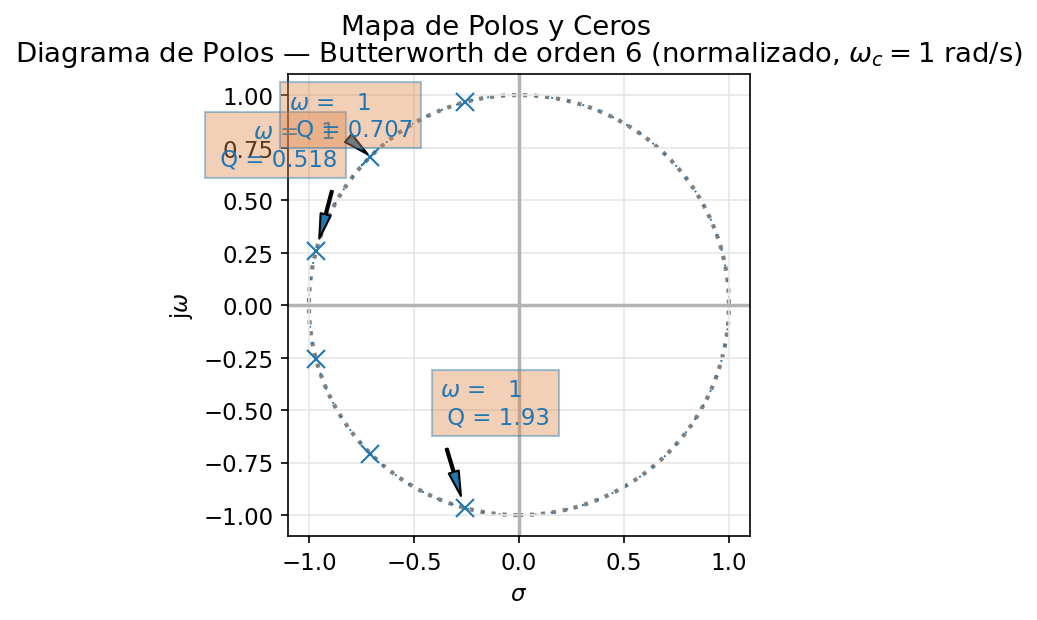

In [3]:
# Diagrama de polos y ceros — Butterworth de orden 6 (sin ceros, solo polos)
pzmap(H_b6, filter_description='Butterworth $n=6$', annotations=True)
plt.title('Diagrama de Polos — Butterworth de orden 6 (normalizado, $\omega_c = 1$ rad/s)')
plt.legend().remove()
plt.show()

<a id="p2"></a>

***

## Punto 2 — Módulo, fase y polos/ceros

### Resolución manuscrita

Originales: `p2_hoja_1.jpg` y `p2_hoja_2.jpg` en [img/](./img/)

<img src="./img/p2_hoja_1.jpg" width="450" />

<img src="./img/p2_hoja_2.jpg" width="450" />

### Desarrollo — Módulo

Partimos de la función de aproximación de Butterworth con $\varepsilon^2 = 1$:

$$
|T(j\omega)| = \frac{1}{\sqrt{1 + \varepsilon^2\,\omega^{2n}}}\,\Bigg|_{\varepsilon^2=1} = \frac{1}{\sqrt{1 + \omega^{2n}}} \quad \mathbf{(1)}
$$

Para $n = 6$:

$$
\boxed{|T(j\omega)| = \frac{1}{\sqrt{1 + \omega^{12}}}} \quad \mathbf{(2)}
$$

**Puntos notables:**

<div align="center">

| $\omega$ | $\|T(j\omega)\|$ | dB |
|:---:|:---:|:---:|
| $0$ | $1$ | $0$ dB |
| $1$ | $\dfrac{1}{\sqrt{2}}$ | $-3$ dB |
| $\to\infty$ | $\to 0$ | $\to -\infty$ |

</div>

**En dB:**

$$
20\log|T(j\omega)| = 20\log\frac{1}{\sqrt{1+\omega^{12}}} = -10\log\!\left(1+\omega^{12}\right) \quad \mathbf{(3)}
$$

**Pendiente asintótica** para $\omega \gg 1$ (el término $\omega^{12}$ domina sobre el 1):

$$
-10\log(\omega^{12}) = -20\cdot 6\cdot\log(\omega) \quad \Longrightarrow \quad \boxed{-120 \text{ dB/dec}} \quad \mathbf{(4)}
$$

### Desarrollo — Fase (método gráfico, cualitativo)

Por el método gráfico, la fase de $T(j\omega)$ es el negativo de la suma de los ángulos de los vectores que van desde cada polo hasta el punto $j\omega$ sobre el eje imaginario:

$$
\angle T(j\omega) = -\sum_{k=1}^{6} \angle(j\omega - P_k) \quad \mathbf{(5)}
$$

---

**$\omega = 0$** — Los vectores de cada par conjugado son simétricamente opuestos respecto al eje real, sus contribuciones angulares se cancelan:

$$
\angle T\big|_{\omega=0} = 0° \quad \mathbf{(6)}
$$

---

**$\omega \to \infty$** — Todos los vectores $j\omega - P_k$ apuntan en la dirección de $j\omega$ (vertical hacia arriba), contribuyendo $+90°$ cada uno. Con $n = 6$ polos:

$$
\angle T\big|_{\omega\to\infty} = -6 \times 90° = -n\cdot\frac{\pi}{2} = -3\pi = -540° \quad \mathbf{(7)}
$$

---

**$\omega = 1$** — Confirmación algebraica: el denominador de cada SOS evaluado en $\omega = 1$ es puramente imaginario:

$$
\bigl(1 - \omega^2\bigr) + j\cdot 2\cos(\phi_k)\cdot\omega\,\Big|_{\omega=1} = j\cdot 2\cos(\phi_k)
$$

Cada SOS aporta exactamente $-90°$, y los tres sumados:

$$
\angle T\big|_{\omega=1} = 3\times(-90°) = -\frac{3\pi}{2} = -270° \quad \mathbf{(8)}
$$

---

**Resumen:**

<div align="center">

| $\omega$ | $\angle T$ |
|:---:|:---:|
| $0$ | $0°$ |
| $1$ | $-270°\;\left(-\dfrac{3\pi}{2}\right)$ |
| $\to\infty$ | $-540°\;(-3\pi)$ |

</div>

La fase es **monótonamente decreciente**, lo que se corresponde con un **retardo de grupo positivo** en toda la banda.

### Verificación con Python

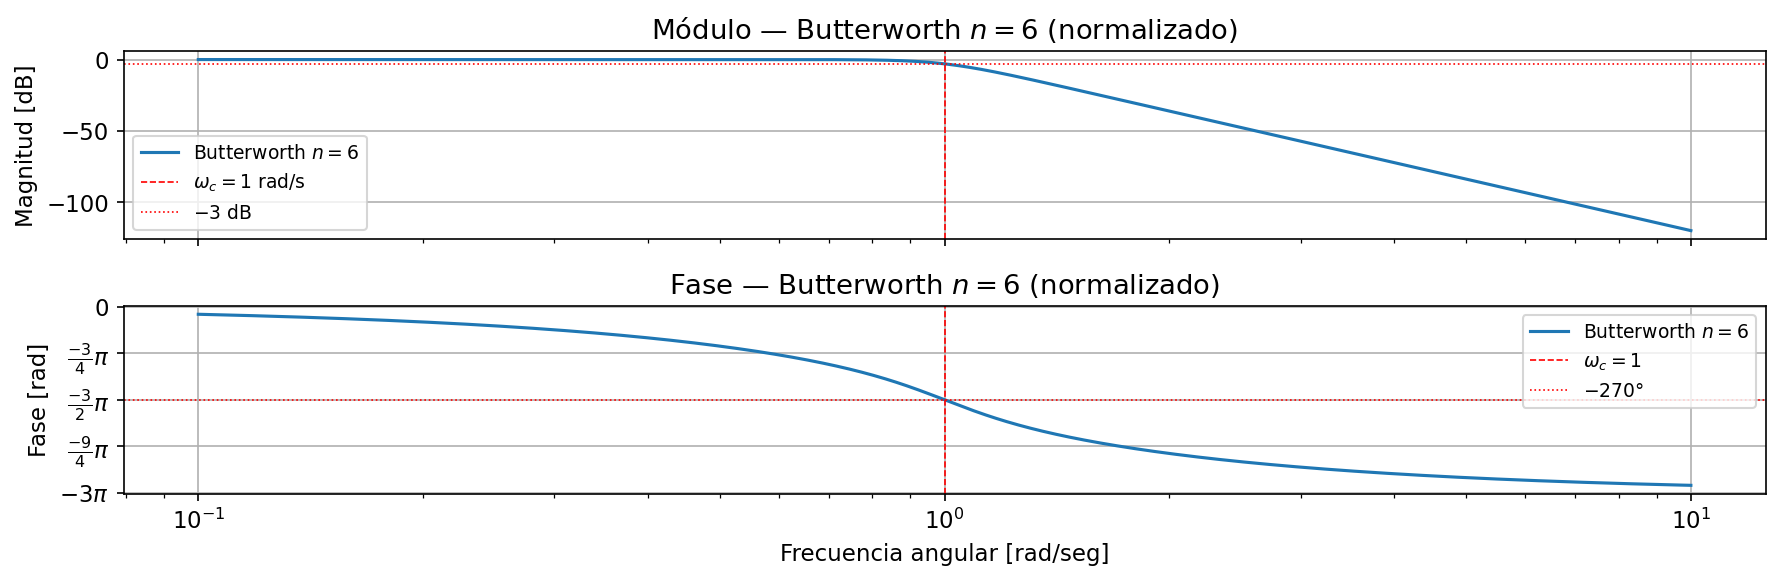

In [4]:
_, axes_hdl = bodePlot(H_b6, filter_description='Butterworth $n=6$')

# Módulo: zoom para ver claramente el punto -3 dB en wc = 1
plt.sca(axes_hdl[0])
plt.axvline(x=1, color='r', linestyle='--', linewidth=0.8, label='$\\omega_c = 1$ rad/s')
plt.axhline(y=-3, color='r', linestyle=':', linewidth=0.8, label='$-3$ dB')
plt.title('Módulo — Butterworth $n=6$ (normalizado)')
plt.legend(fontsize=9)

# Fase: bodePlot usa radianes — -270° = -3π/2 ≈ -4.71 rad
plt.sca(axes_hdl[1])
plt.axvline(x=1, color='r', linestyle='--', linewidth=0.8, label='$\\omega_c = 1$')
plt.axhline(y=-3*np.pi/2, color='r', linestyle=':', linewidth=0.8, label='$-270°$')
plt.title('Fase — Butterworth $n=6$ (normalizado)')
plt.legend(fontsize=9)

plt.tight_layout()
plt.show()

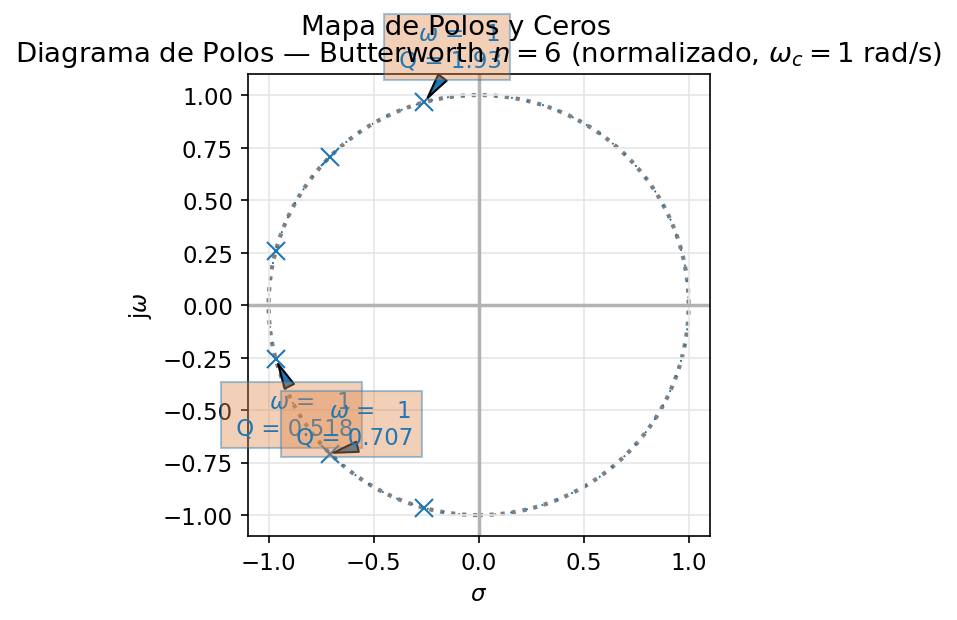

In [5]:
pzmap(H_b6, filter_description='Butterworth $n=6$', annotations=True)
plt.title('Diagrama de Polos — Butterworth $n=6$ (normalizado, $\\omega_c = 1$ rad/s)')
plt.legend().remove()
plt.show()

<a id="p3"></a>

***

## Punto 3 — Síntesis de la red normalizada con SOS

La transferencia de Butterworth $n=6$ se realiza como cascada de tres secciones de segundo orden (SOS). Para cada sección se analiza primero la topología de forma **genérica con admitancias** $Y_k$, y luego se reemplazan los elementos concretos según el tipo de filtro (LPF, HPF, BPF) requerido.

### Resolución manuscrita

---

## 3.1 Topología Sallen-Key (SK)

### Análisis genérico con admitancias

Se considera el circuito SK genérico con seis admitancias $Y_1$–$Y_6$:

- $Y_1, Y_2$: elementos serie en el camino de la señal
- $Y_3$: shunt a tierra desde el nodo $V_y$ (entrada no-inversora del opamp)
- $Y_4$: feedback desde $V_o$ al nodo $V_x$
- $Y_5, Y_6$: divisor resistivo desde $V_o$ a tierra (punto medio al terminal $V^+$)

<div align="center">
<img src="img/p3_sk_gen_1.jpg" width="480"/>
<img src="img/p3_sk_lpf_1.jpg" width="480"/>
</div>

Aplicando Metodo de Nodos y Admitancias en los nodos $V_x$, $V_y$ y en el terminal inversor $V^-$ (con cortocircuito virtual $V^- = V_y$):

$$V_x(Y_1+Y_2+Y_4) - V_i Y_1 - V_y Y_2 - V_o Y_4 = 0 \tag{1}$$

$$V_y(Y_2+Y_3) - V_x Y_2 = 0 \tag{2}$$

$$V_y(Y_5+Y_6) - V_o Y_5 = 0 \tag{3}$$

De (3) se obtiene la tensión en el nodo de entrada del opamp:

$$V_y = V_o \frac{Y_5}{Y_5+Y_6} \tag{4}$$

Sustituyendo (4) en (2):

$$V_x = V_o \frac{Y_5(Y_2+Y_3)}{Y_2(Y_5+Y_6)} \tag{5}$$

Sustituyendo (4) y (5) en (1) y agrupando términos:

$$\boxed{\frac{V_o}{V_i} = \frac{Y_1 Y_2 Y_5 + Y_1 Y_2 Y_6}{Y_1 Y_2 Y_5 + Y_1 Y_3 Y_5 + Y_2 Y_3 Y_5 + Y_3 Y_4 Y_5 - Y_2 Y_4 Y_6}} \quad \mathbf{(6)}$$

### SK — Pasa Bajos (LPF)

Sustitución de elementos: $Y_1 = \tfrac{1}{R_1}$, $Y_2 = \tfrac{1}{R_2}$, $Y_3 = sC_1$, $Y_4 = sC_2$, $Y_5 = \tfrac{1}{R_4}$, $Y_6 = \tfrac{1}{R_3}$.

<div align="center">
<img src="img/p3_circ_sk_lpf_ok.png" width="440"/>
<img src="img/p3_sk_lpf_2.jpg" width="440"/>
</div>

Reemplazando en **(6)** y normalizando por $C_1 C_2 R_1 R_2$:

$$\frac{V_o}{V_i} = \frac{K \dfrac{1}{R_1 R_2 C_1 C_2}}{s^2 + s\,\dfrac{C_1(R_1+R_2) - C_2 R_1 \tfrac{R_4}{R_3}}{R_1 R_2 C_1 C_2} + \dfrac{1}{R_1 R_2 C_1 C_2}} \tag{7}$$

Identificando con la forma canónica biquadrática $\dfrac{K\omega_0^2}{s^2 + s\tfrac{\omega_0}{Q} + \omega_0^2}$:

$$\boxed{K = 1 + \frac{R_4}{R_3}, \qquad \omega_0 = \frac{1}{\sqrt{R_1 R_2 C_1 C_2}}, \qquad Q = \frac{\sqrt{R_1 R_2 C_1 C_2}}{C_1(R_1+R_2) - C_2 R_1 \tfrac{R_4}{R_3}}} \quad \mathbf{(8)}$$

### SK — Pasa Altos (HPF)

Sustitución: $Y_1 = sC_1$, $Y_2 = sC_2$, $Y_3 = \tfrac{1}{R_1}$, $Y_4 = \tfrac{1}{R_2}$, $Y_5 = \tfrac{1}{R_4}$, $Y_6 = \tfrac{1}{R_3}$.

<div align="center">
<img src="img/p3_circ_sk_hpf_ok.png" width="440"/>
<img src="img/p3_sk_hpf_1.jpg" width="440"/>
<img src="img/p3_sk_hpf_2.jpg" width="440"/>
</div>

Reemplazando en **(6)** y normalizando:

$$\frac{V_o}{V_i} = \frac{K\,s^2}{s^2 + s\,\dfrac{(C_1+C_2)R_2 - C_2 R_1 \tfrac{R_4}{R_3}}{R_1 R_2 C_1 C_2} + \dfrac{1}{R_1 R_2 C_1 C_2}} \tag{9}$$

$$\boxed{K = 1 + \frac{R_4}{R_3}, \qquad \omega_0 = \frac{1}{\sqrt{R_1 R_2 C_1 C_2}}, \qquad Q = \frac{\sqrt{R_1 R_2 C_1 C_2}}{(C_1+C_2)R_2 - C_2 R_1 \tfrac{R_4}{R_3}}} \quad \mathbf{(10)}$$

### Verificación simbólica con SymPy — Sallen-Key

In [6]:
import sympy as sp
from pytc2.general import print_subtitle, print_latex, a_equal_b_latex_s

R1, R2, R3, R4, C1, C2 = sp.symbols('R1 R2 R3 R4 C1 C2', positive=True)
Y1, Y2, Y3, Y4, Y5, Y6 = sp.symbols('Y1 Y2 Y3 Y4 Y5 Y6')
Vi, Vx, Vy, Vo = sp.symbols('Vi Vx Vy Vo')

# ── Método de Nodos y Admitancias (3 nodos) ──
eq1 = sp.Eq( Vx*(Y1+Y2+Y4) - Vi*Y1 - Vy*Y2 - Vo*Y4 , 0 )   # MNA — nodo Vx
eq2 = sp.Eq( Vy*(Y2+Y3) - Vx*Y2 ,                     0 )   # MNA — nodo Vy
eq3 = sp.Eq( Vy*(Y5+Y6) - Vo*Y5 ,                     0 )   # MNA — nodo V⁻

print_subtitle('SK — Sistema de ecuaciones (Método de Nodos y Admitancias)')
print_latex(sp.latex(eq1) + r'\quad (1)')
print_latex(sp.latex(eq2) + r'\quad (2)')
print_latex(sp.latex(eq3) + r'\quad (3)')

# Resolver el sistema lineal en (Vx, Vy, Vo)
sol  = sp.solve([eq1, eq2, eq3], [Vx, Vy, Vo])
T_sk = sp.cancel(sol[Vo] / Vi)

print_subtitle('SK — Transferencia genérica obtenida resolviendo (1)–(3)')
print_latex(a_equal_b_latex_s(r'\dfrac{V_o}{V_i}', T_sk))

# ── SK LPF: Y1=1/R1, Y2=1/R2, Y3=sC1, Y4=sC2, Y5=1/R4, Y6=1/R3 ──
T_lpf = normalize(T_sk.subs({Y1:1/R1, Y2:1/R2, Y3:s*C1, Y4:s*C2, Y5:1/R4, Y6:1/R3}))
print_subtitle('SK LPF — sustitución de elementos  [ec. (7)]')
print_latex(a_equal_b_latex_s(r'T_\mathrm{SK\,LPF}(s)', T_lpf))

K, w0, Q = extract_biquad_params(T_lpf, 'LPF')
print_subtitle('SK LPF — Parámetros K, ω₀, Q identificados  [ec. (8)]')
print_latex(a_equal_b_latex_s('K',          K))
print_latex(a_equal_b_latex_s(r'\omega_0',  w0))
print_latex(a_equal_b_latex_s('Q',          Q))

# ── SK HPF: Y1=sC1, Y2=sC2, Y3=1/R1, Y4=1/R2, Y5=1/R4, Y6=1/R3 ──
T_hpf = normalize(T_sk.subs({Y1:s*C1, Y2:s*C2, Y3:1/R1, Y4:1/R2, Y5:1/R4, Y6:1/R3}))
print_subtitle('SK HPF — sustitución de elementos  [ec. (9)]')
print_latex(a_equal_b_latex_s(r'T_\mathrm{SK\,HPF}(s)', T_hpf))

K, w0, Q = extract_biquad_params(T_hpf, 'HPF')
print_subtitle('SK HPF — Parámetros K, ω₀, Q identificados  [ec. (10)]')
print_latex(a_equal_b_latex_s('K',          K))
print_latex(a_equal_b_latex_s(r'\omega_0',  w0))
print_latex(a_equal_b_latex_s('Q',          Q))


#### SK — Sistema de ecuaciones (Método de Nodos y Admitancias)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### SK — Transferencia genérica obtenida resolviendo (1)–(3)

...

<IPython.core.display.Math object>

#### SK HPF — Parámetros K, ω₀, Q identificados  [ec. (10)]

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

---

## 3.2 Topología Multiple Feedback (MFB / Deliyannis-Friend)

### Análisis genérico con admitancias

El circuito MFB tiene cinco admitancias $Y_1$–$Y_5$. El opamp trabaja en configuración **inversora**: $V_y = 0$ (tierra virtual en el terminal $V^-$).

- $Y_1$: feedback desde $V_o$ al nodo $V_x$
- $Y_2$: entrada $V_i$ al nodo $V_x$
- $Y_3$: $V_x$ al nodo $V_y$ (terminal inversor, tierra virtual)
- $Y_4$: shunt a tierra desde $V_x$
- $Y_5$: feedback desde $V_o$ a $V_y$

<div align="center">
<img src="img/p3_mfb_gen_1.jpg" width="480"/>
</div>

Aplicando el Método de Nodos y Admitancias en $V_x$ (con $V_y = 0$):

$$V_x(Y_1+Y_2+Y_3+Y_4) - V_i Y_2 - V_o Y_1 = 0 \tag{11}$$

Método de Nodos y Admitancias en $V_y = 0$:

$$-V_x Y_3 - V_o Y_5 = 0 \quad\Rightarrow\quad V_x = -\frac{V_o\,Y_5}{Y_3} \tag{12}$$

Sustituyendo (12) en (11):

$$\boxed{\frac{V_o}{V_i} = \frac{-Y_2 Y_3}{Y_5(Y_1+Y_2+Y_3+Y_4)+Y_1 Y_3}} \quad \mathbf{(13)}$$

### MFB — Pasa Bajos (LPF)

Sustitución: $Y_1 = \tfrac{1}{R_1}$, $Y_2 = \tfrac{1}{R_3}$, $Y_3 = \tfrac{1}{R_2}$, $Y_4 = sC_1$, $Y_5 = sC_2$.

<div align="center">
<img src="img/p3_circ_mfb_lpf_ok.png" width="440"/>
<img src="img/p3_mfb_lpf_1.jpg" width="440"/>
</div>

Reemplazando en **(13)** y dividiendo numerador y denominador por $C_1 C_2$:

$$\frac{V_o}{V_i} = \frac{-\dfrac{1}{R_2 R_3 C_1 C_2}}{s^2 + s\,\dfrac{R_1 R_2 + R_1 R_3 + R_2 R_3}{R_1 R_2 R_3\, C_1} + \dfrac{1}{R_1 R_2 C_1 C_2}} \tag{14}$$

Identificando con $\dfrac{K\omega_0^2}{s^2 + s\tfrac{\omega_0}{Q} + \omega_0^2}$:

$$\boxed{K = -\frac{R_1}{R_3}, \qquad \omega_0 = \frac{1}{\sqrt{R_1 R_2 C_1 C_2}}, \qquad \frac{\omega_0}{Q} = \frac{R_1 R_2 + R_1 R_3 + R_2 R_3}{R_1 R_2 R_3\,C_1}} \quad \mathbf{(15)}$$

Despejando $Q$ a partir de $\omega_0/(\omega_0/Q)$:

$$\boxed{Q = \frac{R_3\,\sqrt{\dfrac{R_1 R_2 C_1}{C_2}}}{R_1 R_2 + R_1 R_3 + R_2 R_3}} \quad \mathbf{(15')}$$

> La ganancia $K$ resulta **negativa** (topología inversora). El módulo $|K| = R_1/R_3$.

### MFB — Pasa Altos (HPF)

Sustitución: $Y_1 = sC_1$, $Y_2 = sC_3$, $Y_3 = sC_2$, $Y_4 = \tfrac{1}{R_1}$, $Y_5 = \tfrac{1}{R_2}$.

<div align="center">
<img src="img/p3_circ_mfb_hpf_ok.png" width="440"/>
<img src="img/p3_mfb_hpf_1.jpg" width="440"/>
</div>

Reemplazando en **(13)** y dividiendo por $C_1 C_2$:

$$\frac{V_o}{V_i} = \frac{-\dfrac{C_3}{C_1}\,s^2}{s^2 + s\,\dfrac{C_1+C_2+C_3}{R_2 C_1 C_2} + \dfrac{1}{R_1 R_2 C_1 C_2}} \tag{16}$$

Identificando con $\dfrac{K\,s^2}{s^2 + s\tfrac{\omega_0}{Q} + \omega_0^2}$:

$$\boxed{K = -\frac{C_3}{C_1}, \qquad \omega_0 = \frac{1}{\sqrt{R_1 R_2 C_1 C_2}}, \qquad \frac{\omega_0}{Q} = \frac{C_1+C_2+C_3}{R_2 C_1 C_2}} \quad \mathbf{(17)}$$

Despejando $Q$ a partir de $\omega_0/(\omega_0/Q)$:

$$\boxed{Q = \frac{1}{C_1+C_2+C_3}\,\sqrt{\frac{R_2\, C_1 C_2}{R_1}}} \quad \mathbf{(17')}$$

> El numerador $Ks^2$ con $K<0$ es consistente con la topología inversora.

### MFB — Pasa Banda (BPF)

Sustitución: $Y_1 = sC_1$, $Y_2 = \tfrac{1}{R_1}$, $Y_3 = sC_2$, $Y_4 = \tfrac{1}{R_2}$, $Y_5 = \tfrac{1}{R_3}$.

<div align="center">
<img src="img/p3_circ_mfb_bpf_ok.png" width="440"/>
<img src="img/p3_mfb_bpf_1.jpg" width="440"/>
</div>

Reemplazando en **(13)** y dividiendo por $C_1 C_2$:

$$\frac{V_o}{V_i} = \frac{-\dfrac{s}{R_1 C_1}}{s^2 + s\,\dfrac{C_1+C_2}{R_3 C_1 C_2} + \dfrac{R_1+R_2}{R_1 R_2 R_3 C_1 C_2}} \tag{18}$$

Identificando con $\dfrac{K\,\omega_0\,s/Q}{s^2 + s\,\omega_0/Q + \omega_0^2}$:

$$\boxed{K = -\frac{R_3 C_2}{R_1(C_1+C_2)}, \qquad \omega_0 = \sqrt{\frac{R_1+R_2}{R_1 R_2 R_3 C_1 C_2}}, \qquad \frac{\omega_0}{Q} = \frac{C_1+C_2}{R_3 C_1 C_2}} \quad \mathbf{(19)}$$

Despejando $Q$ a partir de $\omega_0/(\omega_0/Q)$:

$$\boxed{Q = \frac{1}{C_1+C_2}\,\sqrt{\frac{(R_1+R_2)\, R_3\, C_1 C_2}{R_1 R_2}}} \quad \mathbf{(19')}$$

### Verificación simbólica con SymPy — MFB (Deliyannis-Friend)

In [7]:
import sympy as sp
from pytc2.general import print_subtitle, print_latex, a_equal_b_latex_s

R1, R2, R3, C1, C2, C3 = sp.symbols('R1 R2 R3 C1 C2 C3', positive=True)
Y1, Y2, Y3, Y4, Y5 = sp.symbols('Y1 Y2 Y3 Y4 Y5')
Vi, Vx, Vo = sp.symbols('Vi Vx Vo')

# ── Método de Nodos y Admitancias: nodos Vx y Vy=0 (tierra virtual) ──
eq1 = sp.Eq( Vx*(Y1+Y2+Y3+Y4) - Vi*Y2 - Vo*Y1 ,  0 )   # MNA — nodo Vx
eq2 = sp.Eq( -Vx*Y3 - Vo*Y5 ,                     0 )   # MNA — nodo Vy=0

print_subtitle('MFB — Sistema de ecuaciones de nodos')
print_latex(sp.latex(eq1) + r'\quad (1)')
print_latex(sp.latex(eq2) + r'\quad (2)')

# Resolver para (Vx, Vo)
sol   = sp.solve([eq1, eq2], [Vx, Vo])
T_mfb = sp.cancel(sol[Vo] / Vi)

print_subtitle('MFB — Transferencia genérica obtenida resolviendo (1)–(2)')
print_latex(a_equal_b_latex_s(r'\dfrac{V_o}{V_i}', T_mfb))

# ── MFB LPF: Y1=1/R1, Y2=1/R3, Y3=1/R2, Y4=sC1, Y5=sC2 ──
T_lpf = normalize(T_mfb.subs({Y1:1/R1, Y2:1/R3, Y3:1/R2, Y4:s*C1, Y5:s*C2}))
print_subtitle('MFB LPF — sustitución de elementos  [ec. (14)]')
print_latex(a_equal_b_latex_s(r'T_\mathrm{MFB\,LPF}(s)', T_lpf))

K, w0, Q = extract_biquad_params(T_lpf, 'LPF')
print_subtitle("MFB LPF — Parámetros K, ω₀, Q identificados  [ec. (15)/(15')]")
print_latex(a_equal_b_latex_s('K',          K))
print_latex(a_equal_b_latex_s(r'\omega_0',  w0))
print_latex(a_equal_b_latex_s('Q',          Q))

# ── MFB HPF: Y1=sC1, Y2=sC3, Y3=sC2, Y4=1/R1, Y5=1/R2 ──
T_hpf = normalize(T_mfb.subs({Y1:s*C1, Y2:s*C3, Y3:s*C2, Y4:1/R1, Y5:1/R2}))
print_subtitle('MFB HPF — sustitución de elementos  [ec. (16)]')
print_latex(a_equal_b_latex_s(r'T_\mathrm{MFB\,HPF}(s)', T_hpf))

K, w0, Q = extract_biquad_params(T_hpf, 'HPF')
print_subtitle("MFB HPF — Parámetros K, ω₀, Q identificados  [ec. (17)/(17')]")
print_latex(a_equal_b_latex_s('K',          K))
print_latex(a_equal_b_latex_s(r'\omega_0',  w0))
print_latex(a_equal_b_latex_s('Q',          Q))

# ── MFB BPF: Y1=sC1, Y2=1/R1, Y3=sC2, Y4=1/R2, Y5=1/R3 ──
T_bpf = normalize(T_mfb.subs({Y1:s*C1, Y2:1/R1, Y3:s*C2, Y4:1/R2, Y5:1/R3}))
print_subtitle('MFB BPF — sustitución de elementos  [ec. (18)]')
print_latex(a_equal_b_latex_s(r'T_\mathrm{MFB\,BPF}(s)', T_bpf))

K, w0, Q = extract_biquad_params(T_bpf, 'BPF')
print_subtitle("MFB BPF — Parámetros K, ω₀, Q identificados  [ec. (19)/(19')]")
print_latex(a_equal_b_latex_s('K',          K))
print_latex(a_equal_b_latex_s(r'\omega_0',  w0))
print_latex(a_equal_b_latex_s('Q',          Q))


#### MFB — Sistema de ecuaciones de nodos

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### MFB — Transferencia genérica obtenida resolviendo (1)–(2)

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

#### MFB BPF — Parámetros K, ω₀, Q identificados  [ec. (19)/(19')]

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

---

## 3.3 Topología Variable de Estado — KHN (Kerwin-Huelsman-Newcomb)

### Análisis genérico

El circuito KHN utiliza **tres opamps**: un sumador-diferencial en la entrada y dos integradores Miller en cascada. Las conductancias $G_1$–$G_7$ y los capacitores $C_1, C_2$ definen las salidas simultáneas LPF ($V_{o1}$), BPF ($V_{o2}$) y HPF ($V_{o3}$).

<div align="center">
<img src="img/p3_circ_khn_ok.png" width="500"/>
<img src="img/p3_khn_gen_1.jpg" width="480"/>
<img src="img/p3_khn_gen_2.jpg" width="480"/>
</div>

Con $V_A, V_G, V_F, V_D$ los nodos de entrada de cada opamp y $V_B, V_C, V_E$ los nodos de salida, aplicando el Método de Nodos y Admitancias:

$$V_A(G_1+G_2+G_3) - V_i G_1 - V_E G_2 - V_B G_3 = 0 \tag{1}$$

$$V_G(G_6+G_7) - 0\cdot G_7 - V_C G_6 = 0 \tag{2}$$

$$V_F(G_4+sC_1) - V_B G_4 - V_C\,sC_1 = 0 \tag{3}$$

$$V_D(G_5+sC_2) - V_C G_5 - V_E\,sC_2 = 0 \tag{4}$$

**Sustituciones (idealidad de los opamps y nombres de salidas):**

$$V_F = 0,\quad V_D = 0,\quad V_A = V_G,\quad V_B = V_{o3},\quad V_C = V_{o2},\quad V_E = V_{o1}$$

Reemplazando en (1)–(4):

$$V_A(G_1+G_2+G_3) - V_i G_1 - V_{o1} G_2 - V_{o3} G_3 = 0 \tag{5}$$

$$V_A(G_6+G_7) - V_{o2} G_6 = 0 \;\Rightarrow\; V_A = V_{o2}\,\frac{G_6}{G_6+G_7} \tag{6}$$

$$-V_{o3} G_4 - V_{o2}\,sC_1 = 0 \;\Rightarrow\; V_{o2} = -V_{o3}\,\frac{G_4}{sC_1} \tag{7}$$

$$-V_{o2} G_5 - V_{o1}\,sC_2 = 0 \;\Rightarrow\; V_{o1} = -V_{o2}\,\frac{G_5}{sC_2} \tag{8}$$

De (8) y (7), las salidas BPF y HPF se expresan en función de $V_{o1}$:

$$V_{o2} = -V_{o1}\,\frac{sC_2}{G_5} \tag{9}$$

$$V_{o3} = V_{o1}\,\frac{s^2 C_1 C_2}{G_4 G_5} \tag{10}$$

Sustituyendo (6), (9) y (10) en (5):

$$V_{o2}\,\frac{G_6(G_1+G_2+G_3)}{G_6+G_7} - V_i G_1 - V_{o1} G_2 - V_{o3} G_3 = 0 \tag{11}$$

Despejando $V_{o1}/V_i$ se obtiene la transferencia LPF:

$$\boxed{\dfrac{V_{o1}}{V_i} = \dfrac{-\dfrac{G_1 G_4 G_5}{G_3 C_1 C_2}}{s^2 + s\,\dfrac{G_4 G_6 (G_1+G_2+G_3)}{G_3 C_1 (G_6+G_7)} + \dfrac{G_2 G_4 G_5}{G_3 C_1 C_2}}} \tag{12}$$

> El desarrollo algebraico completo (incluidas BPF y HPF) se verifica simbólicamente con SymPy más abajo.

### KHN — Caso con componentes iguales y salidas LPF / BPF / HPF

Para simplificar el diseño se toma $R_1 = R_2 = R_3 = R_4 = R_5 = R$ (conductancias $G = 1/R$) y $C_1 = C_2 = C$. $R_6$ y $R_7$ permanecen como parámetros de diseño para fijar $Q$.

<div align="center">
<img src="img/p3_khn_lpf_1.jpg" width="480"/>
<img src="img/p3_khn_bpf_1.jpg" width="480"/>
</div>

Con componentes iguales, el denominador común a las tres salidas resulta:

$$D(s) = s^2 + s\,\frac{3R_7}{(R_6+R_7)RC} + \frac{1}{R^2 C^2} \tag{13}$$

Identificando $\omega_0 = \dfrac{1}{RC}$ y $\dfrac{\omega_0}{Q} = \dfrac{3\omega_0 R_7}{R_6+R_7}$:

$$\boxed{\omega_0 = \frac{1}{RC}, \qquad Q = \frac{R_6+R_7}{3R_7}} \quad \mathbf{(14)}$$

Las tres salidas disponibles simultáneamente son:

<div align="center">

| Salida | Función | $K$ | $\omega_0$ | $Q$ | Forma canónica |
|:---:|:---:|:---:|:---:|:---:|:---:|
| $V_{o1}$ | LPF | $-1$ | $\dfrac{1}{RC}$ | $\dfrac{R_6+R_7}{3R_7}$ | $\dfrac{-\omega_0^2}{s^2 + s\tfrac{\omega_0}{Q} + \omega_0^2}$ |
| $V_{o2}$ | BPF | $Q = \dfrac{R_6+R_7}{3R_7}$ | $\dfrac{1}{RC}$ | $\dfrac{R_6+R_7}{3R_7}$ | $\dfrac{K\,\omega_0 s/Q}{s^2 + s\tfrac{\omega_0}{Q} + \omega_0^2}$ |
| $V_{o3}$ | HPF | $-1$ | $\dfrac{1}{RC}$ | $\dfrac{R_6+R_7}{3R_7}$ | $\dfrac{-s^2}{s^2 + s\tfrac{\omega_0}{Q} + \omega_0^2}$ |

</div>

> La topología KHN permite obtener LPF, BPF y HPF simultáneamente, ajustando $Q$ mediante el divisor $R_6$–$R_7$. Para la salida BPF, la ganancia en la frecuencia de resonancia vale $|T(j\omega_0)| = K = Q$.

### Verificación simbólica con SymPy — KHN (Variable de Estado)

In [8]:
import sympy as sp
from pytc2.general import print_subtitle, print_latex, a_equal_b_latex_s

G1, G2, G3, G4, G5, G6, G7 = sp.symbols('G1 G2 G3 G4 G5 G6 G7', positive=True)
R1, R2, R3, R4, R5, R6, R7 = sp.symbols('R1 R2 R3 R4 R5 R6 R7', positive=True)
C1cap, C2cap = sp.symbols('C1 C2', positive=True)
R, C = sp.symbols('R C', positive=True)
Vi, VA, VG, VB, VC, VD, VE, VF = sp.symbols('Vi VA VG VB VC VD VE VF')
Vo1, Vo2, Vo3 = sp.symbols('Vo1 Vo2 Vo3')

G_to_R = {G1:1/R1, G2:1/R2, G3:1/R3, G4:1/R4, G5:1/R5, G6:1/R6, G7:1/R7}

def express_in_R(T):
    """Sustituye G→1/R, agrupa por potencias de s y factoriza cada coeficiente."""
    T_R = sp.cancel(T.subs(G_to_R))
    num, den = sp.fraction(T_R)
    num_c = sp.collect(sp.expand(num), s, sp.factor)
    den_c = sp.collect(sp.expand(den), s, sp.factor)
    return num_c / den_c

# ── Método de Nodos y Admitancias: 4 nodos (con conductancias G_x) ──
eq1 = sp.Eq( VA*(G1+G2+G3) - Vi*G1 - VE*G2 - VB*G3 ,        0 )
eq2 = sp.Eq( VG*(G6+G7) - VC*G6 ,                           0 )
eq3 = sp.Eq( VF*(G4 + s*C1cap) - VB*G4 - VC*s*C1cap ,       0 )
eq4 = sp.Eq( VD*(G5 + s*C2cap) - VC*G5 - VE*s*C2cap ,       0 )

print_subtitle('KHN — Sistema de 4 ecuaciones de nodos')
print_latex(sp.latex(eq1) + r'\quad (1)')
print_latex(sp.latex(eq2) + r'\quad (2)')
print_latex(sp.latex(eq3) + r'\quad (3)')
print_latex(sp.latex(eq4) + r'\quad (4)')

# Sustituciones por idealidad de los opamps y nombres de salida
subs_id = {VF:0, VD:0, VG:VA, VB:Vo3, VC:Vo2, VE:Vo1}
eq5, eq6, eq7, eq8 = [eq.subs(subs_id) for eq in (eq1, eq2, eq3, eq4)]

print_subtitle('KHN — Tras sustituir VF=VD=0, VG=VA, VB=Vo3, VC=Vo2, VE=Vo1')
print_latex(sp.latex(eq5) + r'\quad (5)')
print_latex(sp.latex(eq6) + r'\quad (6)')
print_latex(sp.latex(eq7) + r'\quad (7)')
print_latex(sp.latex(eq8) + r'\quad (8)')

# Resolver el sistema lineal en (VA, Vo1, Vo2, Vo3)
sol = sp.solve([eq5, eq6, eq7, eq8], [VA, Vo1, Vo2, Vo3])

# Sustituir G_x = 1/R_x y agrupar por potencias de s
T_lpf_gen = express_in_R(sol[Vo1] / Vi)
T_bpf_gen = express_in_R(sol[Vo2] / Vi)
T_hpf_gen = express_in_R(sol[Vo3] / Vi)

print_subtitle('KHN — Transferencias generales en R, agrupadas por potencias de s')
print_latex(a_equal_b_latex_s(r'\dfrac{V_{o1}}{V_i}', T_lpf_gen))
print_latex(a_equal_b_latex_s(r'\dfrac{V_{o2}}{V_i}', T_bpf_gen))
print_latex(a_equal_b_latex_s(r'\dfrac{V_{o3}}{V_i}', T_hpf_gen))

# ── Caso componentes iguales: R1=R2=R3=R4=R5=R, C1=C2=C ──
equal = {R1:R, R2:R, R3:R, R4:R, R5:R, C1cap:C, C2cap:C}
T_lpf = normalize(T_lpf_gen.subs(equal))
T_bpf = normalize(T_bpf_gen.subs(equal))
T_hpf = normalize(T_hpf_gen.subs(equal))

print_subtitle('KHN — Caso componentes iguales  [ec. (13) y (14)]')
print_latex(a_equal_b_latex_s(r'T_\mathrm{LPF}(s)', T_lpf))
print_latex(a_equal_b_latex_s(r'T_\mathrm{BPF}(s)', T_bpf))
print_latex(a_equal_b_latex_s(r'T_\mathrm{HPF}(s)', T_hpf))

# ── Identificación de ω0 y Q desde el denominador de T_lpf ──
# sp.cancel(T_lpf) re-multiplica num/den para limpiar fracciones, así que el
# denominador resultante NO es mónico. Hay que extraer las razones a0/a2 y a1/a2.
_, den = sp.fraction(sp.cancel(T_lpf))
den_exp = sp.expand(den)
a2 = den_exp.coeff(s, 2)
a1 = den_exp.coeff(s, 1)
a0 = den_exp.coeff(s, 0)
w0sq = sp.simplify(a0 / a2)
w0Q  = sp.simplify(a1 / a2)
w0   = sp.sqrt(w0sq)
Q    = sp.simplify(w0 / w0Q)

print_subtitle('KHN — Parámetros identificados')
print_latex(a_equal_b_latex_s(r'\omega_0', sp.simplify(w0)))
print_latex(a_equal_b_latex_s(r'Q', Q))


#### KHN — Sistema de 4 ecuaciones de nodos

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### KHN — Parámetros identificados

<IPython.core.display.Math object>

<IPython.core.display.Math object>

---

## 3.4 Síntesis del Butterworth $n=6$ — cascada de las 3 SOS

Con las transferencias LPF de cada topología (SK, KHN, MFB) ya derivadas en 3.1–3.3, ahora **se asignan los pares de polos a las topologías** según el ordenamiento $Q_1<Q_2<Q_3$ de la consigna y se dimensionan los componentes para que cada SOS realice **exactamente** el factor cuadrático correspondiente del Butterworth normalizado de orden 6.

### Resolución manuscrita

<div align="center">
<img src="img/p3_4_hoja_1.jpg" width="500"/>
<img src="img/p3_4_hoja_2.jpg" width="500"/>
<img src="img/p3_4_hoja_3.jpg" width="500"/>
<img src="img/p3_4_hoja_4.jpg" width="500"/>
</div>

### Transcripción en LaTeX

#### Transferencias objetivo (a igualar)

Las tres transferencias pasa-bajos derivadas previamente son las que se van a sintonizar:

$$T(s)\big|_1 = \dfrac{\left(1+\dfrac{R_4}{R_3}\right)\dfrac{1}{R_1 R_2 C_1 C_2}}{s^2 + s\,\dfrac{C_1(R_1+R_2) - R_1\dfrac{R_4}{R_3}\,C_2}{R_1 R_2 C_1 C_2} + \dfrac{1}{R_1 R_2 C_1 C_2}} \quad \textbf{Sallen-Key LPF}$$

$$T(s)\big|_2 = \dfrac{-\dfrac{1}{R^2 C^2}}{s^2 + s\,\dfrac{3R_7}{(R_6+R_7)\,RC} + \dfrac{1}{R^2 C^2}} \quad \textbf{KHN LPF}$$

$$T(s)\big|_3 = \dfrac{-\dfrac{1}{C_1 C_2 R_2 R_3}}{s^2 + s\,\dfrac{R_2 R_3 + R_1 R_3 + R_1 R_2}{R_1 R_2 R_3\, C_1} + \dfrac{1}{C_1 C_2 R_1 R_2}} \quad \textbf{MFB LPF}$$

#### Asignación SOS ↔ par de polos

Con $Q_1 < Q_2 < Q_3$ y los ángulos del Punto 1, la asignación de la consigna queda:

<div align="center">

| SOS | Topología | $\phi_k$ | $Q_k = \dfrac{1}{2\cos\phi_k}$ |
|:---:|:---:|:---:|:---:|
| 1 | **Sallen-Key** | $\dfrac{\pi}{12}$ | $\approx 0{,}518$ |
| 2 | **KHN**        | $\dfrac{\pi}{4}$  | $\approx 0{,}707$ |
| 3 | **MFB**        | $\dfrac{5\pi}{12}$ | $\approx 1{,}932$ |

</div>

> En un LPF normalizado: $\dfrac{1}{Q} = 2\cos\phi$.

#### SOS 1 — Sallen-Key

**Objetivo:** $T(s)\big|_1 = \dfrac{1}{s^2 + 2\cos(\pi/12)\,s + 1}$, es decir $K_1 = 1$, $\omega_0 = 1$ rad/s, $Q_\text{SK} = \dfrac{1}{2\cos(\pi/12)}$.

**Ganancia:** $K = 1+\dfrac{R_4}{R_3} = 1 \;\Rightarrow\; R_4 = 0$ (cable) y $R_3$ desconectado. El opamp queda con realimentación tipo **seguidor** (lazo directo $V_o \to V^-$).

Quedan $R_1, R_2, C_1, C_2$ — 4 grados de libertad. Eligiendo $R_1 = R_2 = R$ se reducen a 3:

$$\omega_0 = \dfrac{1}{R\sqrt{C_1 C_2}}, \qquad Q = \dfrac{R\sqrt{C_1 C_2}}{C_1\cdot 2R} = \dfrac{1}{2}\sqrt{\dfrac{C_2}{C_1}}$$

Imponiendo $\omega_0^2 = 1 = \dfrac{1}{R^2 C_1 C_2}$ y $Q$ definido:

$$\dfrac{C_2}{C_1} = 4Q^2 \tag{1}$$

Eligiendo además $R = 1\,\Omega$:

$$C_1\,C_2 = 1 \tag{2}$$

De (2): $\;C_1 = \dfrac{1}{C_2}\;$ (3). Sustituyendo (3) en (1):

$$C_2^2 = 4Q^2 = \dfrac{1}{\cos^2(\pi/12)} \approx 1{,}07179$$

$$\boxed{\;C_2 = 1{,}0353\,\text{F}, \quad C_1 = 0{,}9659\,\text{F}, \quad R_1 = R_2 = 1\,\Omega, \quad R_4 = 0,\; R_3\text{ desconectado}\;}$$

#### SOS 2 — KHN

**Objetivo:** $T(s)\big|_2 = \dfrac{-1}{s^2 + 2\cos(\pi/4)\,s + 1} = \dfrac{-1}{s^2 + \sqrt{2}\,s + 1}$, con $|K_2| = 1$.

Con componentes iguales del KHN: $\omega_0 = \dfrac{1}{RC}$, $Q = \dfrac{R_6+R_7}{3R_7}$, $|K| = 1$.

Eligiendo $R = 1\,\Omega$ y $C = 1\,\text{F}$ se obtiene $\omega_0 = 1$ rad/s.

Para $Q = 1/\sqrt{2}$:

$$\dfrac{1}{\sqrt{2}} = \dfrac{R_6 + R_7}{3 R_7} \;\Rightarrow\; 3R_7\,Q - R_7 = R_6 \;\Rightarrow\; R_7\,(3Q-1) = R_6$$

Eligiendo $R_7 = 1\,\Omega$:

$$R_6 = 1\cdot\left(\dfrac{3}{\sqrt{2}} - 1\right) \approx 1{,}1213\,\Omega$$

$$\boxed{\;R_1 = R_2 = R_3 = R_4 = R_5 = 1\,\Omega, \quad C_1 = C_2 = 1\,\text{F}, \quad R_7 = 1\,\Omega, \quad R_6 \approx 1{,}1213\,\Omega\;}$$

#### SOS 3 — MFB

**Objetivo:** $T(s)\big|_3 = \dfrac{-1}{s^2 + 2\cos(5\pi/12)\,s + 1}$, con $|K_3| = 1$.

Para MFB LPF: $|K| = \dfrac{R_1}{R_3}$, $\;\omega_0^2 = \dfrac{1}{R_1 R_2 C_1 C_2}$, $\;\dfrac{\omega_0}{Q} = \dfrac{R_2 R_3 + R_1 R_3 + R_1 R_2}{R_1 R_2 R_3\,C_1}$.

Eligiendo $R_1 = R_2 = R_3 = R$ se obtiene $|K| = 1$ y se simplifican las restantes:

$$\omega_0^2 = \dfrac{1}{R^2 C_1 C_2} = 1 \tag{1}$$

$$\dfrac{\omega_0}{Q} = \dfrac{3R^2}{R^3\,C_1} = \dfrac{3}{R\,C_1} \tag{2}$$

De (1): $\;R = \dfrac{1}{\sqrt{C_1 C_2}}\;$ (3). Sustituyendo (3) en (2):

$$\dfrac{1}{Q} = 3\sqrt{\dfrac{C_2}{C_1}} \tag{4}$$

Definiendo $R = 1$, de (1) sale $\;C_1 = \dfrac{1}{C_2}\;$ (5). Sustituyendo (5) en (4):

$$3\sqrt{\dfrac{C_2}{1/C_2}} = 3\,C_2 = \dfrac{1}{Q} \;\Rightarrow\; C_2 = \dfrac{2\cos(5\pi/12)}{3} \approx 0{,}1725\,\text{F}$$

$$C_1 = \dfrac{1}{C_2} = 3Q \approx 5{,}7956\,\text{F}$$

$$\boxed{\;R_1 = R_2 = R_3 = 1\,\Omega, \quad C_1 \approx 5{,}7956\,\text{F}, \quad C_2 \approx 0{,}1725\,\text{F}\;}$$

#### Cascada completa

Las tres SOS se interconectan mediante **buffers (AO en seguidor)** para garantizar aislamiento de impedancias entre etapas:

$$V_i \;\to\; \boxed{\text{SOS 1 (SK)}} \;\to\; \boxed{\text{Buffer}} \;\to\; \boxed{\text{SOS 2 (KHN)}} \;\to\; \boxed{\text{Buffer}} \;\to\; \boxed{\text{SOS 3 (MFB)}} \;\to\; V_o$$

**Tabla resumen de componentes** (red normalizada $\omega_0 = 1$ rad/s):

<div align="center">

| SOS | Topología | $K_k$ | Componentes |
|:---:|:---:|:---:|:---|
| 1 | SK gain unitario | $+1$ | $R_1{=}R_2{=}1\,\Omega$, $C_1{\approx}0{,}966$ F, $C_2{\approx}1{,}035$ F (sin $R_3$ ni $R_4$, opamp seguidor) |
| 2 | KHN | $-1$ | $R_1{=}\dots{=}R_5{=}1\,\Omega$, $C_1{=}C_2{=}1$ F, $R_7{=}1\,\Omega$, $R_6{\approx}1{,}1213\,\Omega$ |
| 3 | MFB | $-1$ | $R_1{=}R_2{=}R_3{=}1\,\Omega$, $C_1{\approx}5{,}796$ F, $C_2{\approx}0{,}173$ F |

</div>

**Ganancia total:** $K_\text{tot} = (+1)\cdot(-1)\cdot(-1) = +1$ ✓ (filtro normalizado, sin ganancia neta).

> En el **Punto 5** se verificará en LTSpice que esta cascada con los valores anteriores reproduce exactamente el patrón de descarga del Butterworth $n=6$ (la verificación numérica con `scipy` se hace en la celda siguiente).

#### Parámetros de cada SOS reconstruidos con los R y C calculados

  SOS1 SK : K = +1.0000   ω0 = 1.0000   Q = 0.5177   (Q_ideal = 0.5176)
  SOS2 KHN: K = -1.0000   ω0 = 1.0000   Q = 0.7071   (Q_ideal = 0.7071)
  SOS3 MFB: K = -1.0000   ω0 = 1.0001   Q = 1.9321   (Q_ideal = 1.9319)


#### Cascada con los R y C reales vs Butterworth n=6 (referencia)

  Numerador cascada      : [1.000263]
  Numerador referencia   : [1.]
  Denominador cascada    : [1.     3.8637 7.4643 9.1424 7.4653 3.8645 1.0003]
  Denominador referencia : [1.     3.8637 7.4641 9.1416 7.4641 3.8637 1.    ]

  ¿Denominadores ≈ iguales?  True
  |H(0)| cascada  = 1.0003   (Butterworth = 1.0000)


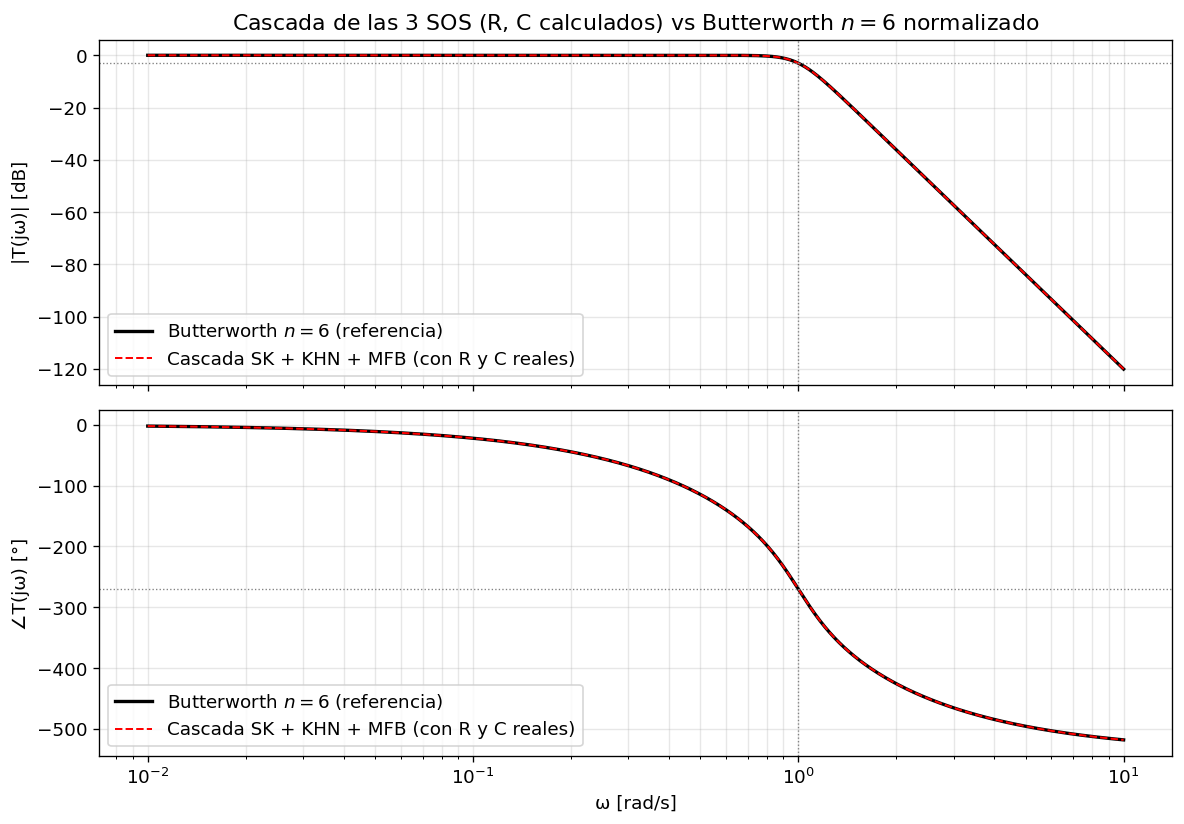

  ∠T(jω0) cascada    = -269.97°   (esperado: −270°)
  ∠T(jω0) referencia = -270.00°


In [9]:
import numpy as np
from scipy import signal as sig
from pytc2.general import print_subtitle
import matplotlib.pyplot as plt

# ──────────────────────────────────────────────────────────────────────
# Verificación: armamos cada SOS con los valores R y C calculados en el
# Punto 3 y los reemplazamos en la transferencia simbólica que dedujimos
# para cada topología. La idea es comprobar que esos componentes —no los
# Q "ideales"— ya producen el Butterworth n=6 de referencia.
# ──────────────────────────────────────────────────────────────────────

# ─ SOS1: Sallen-Key (K = 1, R3 → ∞, R4 = 0) ─
#   T_SK(s) = 1 / ( R1 R2 C1 C2 s² + C1 (R1+R2) s + 1 )     [sección 3.1]
R1_sk, R2_sk = 1.0, 1.0
C1_sk, C2_sk = 0.9659, 1.0353
T_SK = sig.TransferFunction(
    [1.0],
    [R1_sk*R2_sk*C1_sk*C2_sk, C1_sk*(R1_sk + R2_sk), 1.0],
)

# ─ SOS2: KHN componentes iguales (R1..R5 = R, C1 = C2 = C, R7 = 1, R6 calculado) ─
#   ω0 = 1/(R C),   Q = (1 + R6/R7)/3,   K_LPF = -1            [sección 3.3]
R_khn, C_khn = 1.0, 1.0
R6_khn, R7_khn = 1.1213, 1.0
w0_khn = 1.0/(R_khn*C_khn)
Q_khn  = (1.0 + R6_khn/R7_khn)/3.0
T_KHN = sig.TransferFunction(
    [-w0_khn**2],
    [1.0, w0_khn/Q_khn, w0_khn**2],
)

# ─ SOS3: MFB con R iguales (R1 = R2 = R3 = R) ─
#   T_MFB(s) = -1 / ( R² C1 C2 s² + 3 R C2 s + 1 )            [sección 3.2]
R_mfb = 1.0
C1_mfb, C2_mfb = 5.7956, 0.1725
T_MFB = sig.TransferFunction(
    [-1.0],
    [R_mfb**2 * C1_mfb*C2_mfb, 3*R_mfb*C2_mfb, 1.0],
)

# Cascada (buffers ideales: sin carga entre etapas)
num_cas = np.polymul(np.polymul(T_SK.num, T_KHN.num), T_MFB.num)
den_cas = np.polymul(np.polymul(T_SK.den, T_KHN.den), T_MFB.den)
# Normalizamos al coef líder del denominador para comparar con el monico de referencia
num_cas = num_cas / den_cas[0]
den_cas = den_cas / den_cas[0]
T_cas = sig.TransferFunction(num_cas, den_cas)

# Butterworth n=6 de referencia (mismo polinomio que en Punto 1)
phi = np.array([np.pi/12, np.pi/4, 5*np.pi/12])
den_ref = np.array([1.0])
for p in phi:
    den_ref = np.polymul(den_ref, [1.0, 2*np.cos(p), 1.0])
T_ref = sig.TransferFunction([1.0], den_ref)

# ── Reportar K, ω0, Q de cada SOS construido con los R y C reales ─────
def biquad_params(T):
    a2, a1, a0 = T.den
    w0 = np.sqrt(a0/a2)
    Q  = w0*a2/a1
    K  = T.num[-1]/a0
    return K, w0, Q

print_subtitle('Parámetros de cada SOS reconstruidos con los R y C calculados')
for nombre, T, phi_k in [('SOS1 SK ', T_SK,  phi[0]),
                         ('SOS2 KHN', T_KHN, phi[1]),
                         ('SOS3 MFB', T_MFB, phi[2])]:
    K, w0, Q = biquad_params(T)
    Q_ideal = 1/(2*np.cos(phi_k))
    print(f'  {nombre}: K = {K:+.4f}   ω0 = {w0:.4f}   '
          f'Q = {Q:.4f}   (Q_ideal = {Q_ideal:.4f})')

print_subtitle('Cascada con los R y C reales vs Butterworth n=6 (referencia)')
print(f'  Numerador cascada      : {np.round(num_cas, 6)}')
print(f'  Numerador referencia   : {np.round(T_ref.num, 6)}')
print(f'  Denominador cascada    : {np.round(den_cas, 4)}')
print(f'  Denominador referencia : {np.round(T_ref.den, 4)}')
print(f'\n  ¿Denominadores ≈ iguales?  '
      f'{np.allclose(den_cas, T_ref.den, rtol=1e-3, atol=1e-3)}')
print(f'  |H(0)| cascada  = {abs(num_cas[-1]):.4f}   '
      f'(Butterworth = {abs(T_ref.num[-1]):.4f})')

# ── Comparación en Bode: módulo y fase ──────────────────────────────
w = np.logspace(-2, 1, 1000)
_, mag_cas, ph_cas = sig.bode(T_cas, w)
_, mag_ref, ph_ref = sig.bode(T_ref, w)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), dpi=120, sharex=True)

ax1.semilogx(w, mag_ref, 'k-',  lw=2,   label='Butterworth $n=6$ (referencia)')
ax1.semilogx(w, mag_cas, 'r--', lw=1.2, label='Cascada SK + KHN + MFB (con R y C reales)')
ax1.axvline(1,  color='gray', ls=':', lw=0.8)
ax1.axhline(-3, color='gray', ls=':', lw=0.8)
ax1.set_ylabel('|T(jω)| [dB]')
ax1.set_title('Cascada de las 3 SOS (R, C calculados) vs Butterworth $n=6$ normalizado')
ax1.grid(True, which='both', alpha=0.3)
ax1.legend()

ax2.semilogx(w, ph_ref, 'k-',  lw=2,   label='Butterworth $n=6$ (referencia)')
ax2.semilogx(w, ph_cas, 'r--', lw=1.2, label='Cascada SK + KHN + MFB (con R y C reales)')
ax2.axvline(1,  color='gray', ls=':', lw=0.8)
ax2.axhline(-270, color='gray', ls=':', lw=0.8)
ax2.set_xlabel('ω [rad/s]')
ax2.set_ylabel('∠T(jω) [°]')
ax2.grid(True, which='both', alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Verificación explícita de la fase en ω0=1
w0_idx = np.argmin(np.abs(w - 1.0))
print(f'  ∠T(jω0) cascada    = {ph_cas[w0_idx]:.2f}°   (esperado: −270°)')
print(f'  ∠T(jω0) referencia = {ph_ref[w0_idx]:.2f}°')


### 3.5 Retardo de grupo — expresión analítica y gráfica

El **retardo de grupo** $\tau_g(\omega)$ cuantifica el retraso que sufre la envolvente de una señal de banda angosta centrada en $\omega$:

$$\boxed{\;\tau_g(\omega) = -\frac{d\,\angle H(j\omega)}{d\omega}\;}$$

#### Derivación para un biquad LPF normalizado

Cada SOS tiene la forma $T_k(s) = K_k / (s^2 + s/Q_k + 1)$ con $\omega_0 = 1$. La respuesta en frecuencia es

$$H_k(j\omega) = \frac{K_k}{\underbrace{(1 - \omega^2)}_{\text{parte real}} + j\underbrace{(\omega/Q_k)}_{\text{parte imag.}}}$$

La fase (el signo de $K_k = \pm 1$ es constante, no afecta la derivada) es

$$\angle H_k(j\omega) = \text{cte} - \arctan\!\left(\frac{\omega/Q_k}{1 - \omega^2}\right)$$

Derivando respecto de $\omega$ (regla de la cadena sobre el $\arctan$ con argumento $u = \dfrac{\omega}{Q_k(1-\omega^2)}$):

$$\tau_k(\omega) = \frac{d(\arctan u)}{d\omega} = \frac{1}{1+u^2}\cdot\frac{du}{d\omega}$$

con

$$\frac{du}{d\omega} = \frac{(1-\omega^2) + 2\omega^2}{Q_k(1-\omega^2)^2} = \frac{1+\omega^2}{Q_k(1-\omega^2)^2}, \qquad 1 + u^2 = \frac{Q_k^2(1-\omega^2)^2 + \omega^2}{Q_k^2(1-\omega^2)^2}$$

Sustituyendo y simplificando:

$$\boxed{\;\tau_k(\omega) = \frac{(1/Q_k)\,(1 + \omega^2)}{\left(1 - \omega^2\right)^2 + \left(\omega/Q_k\right)^2}\;}$$

Para la etapa RC de primer orden $T_\text{RC} = 1/(s+1)$, el mismo procedimiento da directamente $\tau_\text{RC}(\omega) = 1/(1+\omega^2)$. > **Nota:** esta sección de primer orden **no se utiliza en el Butterworth $n=6$** (que solo tiene pares conjugados). Se incluye aquí como referencia para el **Bonus 2**, donde el Butterworth $n=7$ (orden impar) requiere un polo real en $s=-1$ realizado con un divisor RC.

#### Casos notables que aparecen en el código

Como la cascada usa buffers ideales, el retardo total es la **suma** de los individuales:

$$\tau_g(\omega) = \sum_k \tau_k(\omega)$$

**En $\omega = 0$ (DC):** el denominador vale $1$ y el numerador $1/Q_k$, por lo que

$$\tau_k(0) = \frac{1}{Q_k} \;\;\Rightarrow\;\; \tau_g(0) = \sum_k \frac{1}{Q_k}$$

Para $n=6$: $\;\tau_g(0) = \tfrac{1}{Q_1} + \tfrac{1}{Q_2} + \tfrac{1}{Q_3} = 1{,}932 + 1{,}414 + 0{,}518 = 3{,}864\;\text{s}$.

**En $\omega = \omega_0 = 1$ (frecuencia de corte):** el término $(1-\omega^2)^2 = 0$, así que

$$\tau_k(1) = \frac{(1/Q_k)\cdot 2}{(1/Q_k)^2} = 2Q_k \;\;\Rightarrow\;\; \tau_g(\omega_0) = 2\sum_k Q_k$$

Para $n=6$: $\;\tau_g(1) = 2(Q_1+Q_2+Q_3) = 2(0{,}518+0{,}707+1{,}932) = 6{,}313\;\text{s}$.

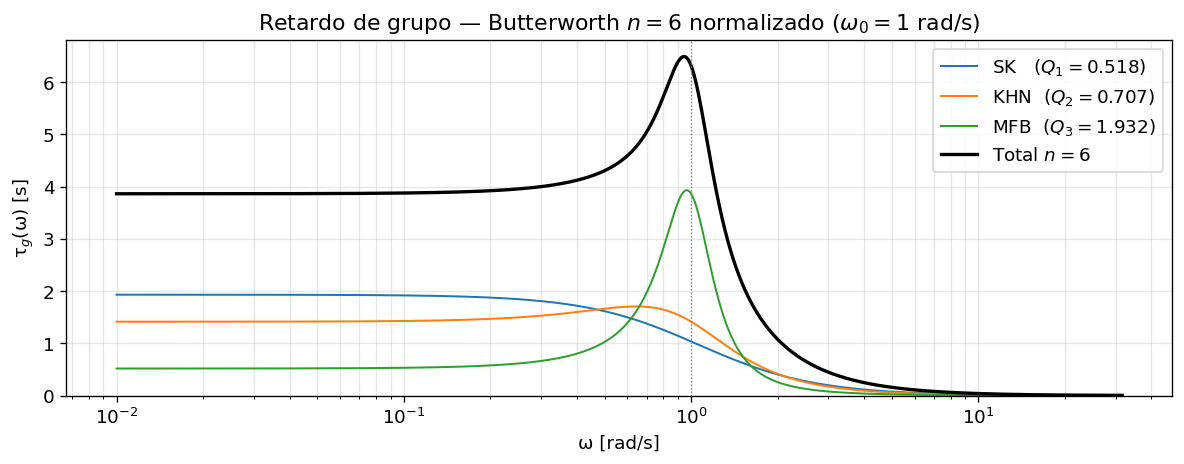

#### Verificación de los valores analíticos

  τ_g(0)  — fórmula: Σ 1/Q_k = 3.864 s
           numérico: 3.864 s  ✓

  τ_g(ω0) — fórmula: 2·Σ Q_k = 6.313 s
           numérico: 6.308 s  ✓


In [10]:
# ── Retardo de grupo — Butterworth n=6 ──
# Calcula τ_g(ω) = -d∠H(jω)/dω numéricamente y verifica los valores analíticos.
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt
from pytc2.general import print_subtitle

phi6  = np.array([np.pi/12, 3*np.pi/12, 5*np.pi/12])
Q1_6, Q2_6, Q3_6 = 1/(2*np.cos(phi6))
C1_sk6, C2_sk6 = 1/(2*Q1_6), 2*Q1_6
C1_mfb6, C2_mfb6 = 3*Q3_6, 1/(3*Q3_6)
T_SK6  = sig.TransferFunction([1.0], [C1_sk6*C2_sk6, 2*C1_sk6, 1.0])
T_KHN6 = sig.TransferFunction([-1.0], [1.0, 1/Q2_6, 1.0])
T_MFB6 = sig.TransferFunction([-1.0], [C1_mfb6*C2_mfb6, 3*C2_mfb6, 1.0])

def group_delay_ct(T, w):
    # τ_g(ω) = -d∠H(jω)/dω  por diferenciación numérica de la fase
    _, H = sig.freqs(T.num, T.den, worN=w)
    phi = np.unwrap(np.angle(H))
    return -np.gradient(phi, w)

w = np.logspace(-2, 1.5, 3000)
tau_sk  = group_delay_ct(T_SK6,  w)
tau_khn = group_delay_ct(T_KHN6, w)
tau_mfb = group_delay_ct(T_MFB6, w)
# τ_total = suma (propiedad de la cascada con buffers)
tau_tot = tau_sk + tau_khn + tau_mfb

fig, ax = plt.subplots(figsize=(10, 4), dpi=120)
ax.semilogx(w, tau_sk,  label=f'SK   ($Q_1={Q1_6:.3f}$)', lw=1.2)
ax.semilogx(w, tau_khn, label=f'KHN  ($Q_2={Q2_6:.3f}$)', lw=1.2)
ax.semilogx(w, tau_mfb, label=f'MFB  ($Q_3={Q3_6:.3f}$)', lw=1.2)
ax.semilogx(w, tau_tot, 'k-', lw=2,   label='Total $n=6$')
ax.axvline(1, color='gray', ls=':', lw=0.8)
ax.set_xlabel('ω [rad/s]'); ax.set_ylabel('τ$_g$(ω) [s]')
ax.set_title('Retardo de grupo — Butterworth $n=6$ normalizado ($\omega_0=1$ rad/s)')
ax.set_ylim(0, None); ax.grid(True, which='both', alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

# ── Verificación de los casos analíticos ──
w0_idx = np.argmin(np.abs(w - 1.0))
dc_idx = np.argmin(np.abs(w - 0.01))
print_subtitle('Verificación de los valores analíticos')
print(f'  τ_g(0)  — fórmula: Σ 1/Q_k = {1/Q1_6+1/Q2_6+1/Q3_6:.3f} s')
print(f'           numérico: {tau_tot[dc_idx]:.3f} s  ✓')
print()
print(f'  τ_g(ω0) — fórmula: 2·Σ Q_k = {2*(Q1_6+Q2_6+Q3_6):.3f} s')
print(f'           numérico: {tau_tot[w0_idx]:.3f} s  ✓')


---

### Verificación en LTSpice — cascada normalizada

Se simula en LTSpice la cascada SK + Buffer + KHN + Buffer + MFB con los valores normalizados ($\omega_0 = 1$ rad/s) y se compara contra el Butterworth $n=6$ esperado. La frecuencia normalizada $\omega_0 = 1$ rad/s en LTSpice cae en $f_0 = 1/(2\pi) \approx 159{,}15$ mHz.

#### 1) Esquema completo simulado

<div align="center">
<img src="img/p5_lt_circuito.jpg" width="900"/>
</div>

Las tres SOS están dibujadas dentro de cuadros punteados con los valores del diseño (SOS1 = SK con $C_1=0{,}9659$, $C_2=1{,}0353$ y $R_3=100\,\text{M}\Omega \to$ desconectado; SOS2 = KHN con $R_6=1{,}1213$ y resto a 1; SOS3 = MFB con $C_1=5{,}7956$, $C_2=0{,}1725$). Los **buffers** $U_2$ y $U_6$ entre etapas son AO en seguidor. Directiva: `.ac dec 100 0.001 40` y `.lib opamp.sub`.

Las salidas relevantes están etiquetadas: `Vo_sk`, `Vo_lpf_khn` y `Vo` (salida final tras el MFB).

#### 2) Bode de módulo (escala dB) — pendiente total $-120$ dB/dec

<div align="center">
<img src="img/p5_lt_bode_db.jpg" width="900"/>
</div>

Cuatro trazas superpuestas:

- **Cyan (`V(vo)/V(vin)`)** — cascada total. Cae con pendiente **$-120$ dB/dec** (la suma de las tres pendientes individuales $3 \times -40 = -120$ dB/dec, equivalentes a $n=6$ polos $\to -20\cdot 6$).
- **Verde (`V(vo_lpf_khn)/V(vi_khn)`)** — KHN solo, pendiente $-40$ dB/dec.
- **Roja (`V(vo)/V(vi_mfb)`)** — MFB solo, pendiente $-40$ dB/dec con pico pronunciado en $\omega_0$ por su $Q_3 \approx 1{,}93$.
- **Azul (`V(vo_sk)/V(vin)`)** — SK solo, pendiente $-40$ dB/dec, sin pico (Q bajo).

Las tres SOS individuales se cruzan en banda de paso en 0 dB y se separan después en $\omega_0$ por sus distintos $Q$.

**Cursor sobre la cascada total a $\omega_0$** ($f_0 = 1/(2\pi) \approx 159{,}15$ mHz):

<div align="center">
<img src="img/p5_lt_db_3db.jpg" width="900"/>
</div>

A $f = 159{,}77$ mHz el cursor sobre $V(\text{vo})/V(\text{vin})$ marca **$-3{,}11$ dB** $\approx -3$ dB ✓. Es la propiedad definitoria del Butterworth: $|H(j\omega_0)| = 1/\sqrt{2}$ ($-3{,}01$ dB) **para cualquier orden $n$**, ya que $\omega_0$ es por construcción la frecuencia de corte. La fase en el mismo punto: $-271{,}35° \approx -270°$, también consistente con $n \cdot 90°/2 = 270°$.

#### 3) Escala lineal — verificación de $|T(j\omega_0)| = Q$ para cada SOS

<div align="center">
<img src="img/p5_lt_lineal.jpg" width="900"/>
</div>

En escala lineal de magnitud se ven claramente los picos en $\omega_0$ que predice la teoría: para una SOS LPF $|T(j\omega_0)| = K \cdot Q$ (con $K = \pm 1$ en nuestro diseño, $|T(j\omega_0)| = Q_k$).

> **Nota:** en la misma gráfica, la **traza total** $V(\text{vo})/V(\text{vin})$ también pasa por $1/\sqrt{2} \approx 0{,}7071$ en $\omega_0 = 1$ rad/s. Esto **no** es coincidencia con el $Q_2$ del KHN: es la propiedad definitoria del Butterworth, $|H(j\omega_0)| = 1/\sqrt{2}$ ($-3$ dB) **para cualquier orden $n$**, porque por construcción $\omega_0$ es la frecuencia de corte. Que numéricamente coincida con $Q_2 = 1/\sqrt{2}$ es algo propio de Butterworth $n=6$ (el SOS central tiene siempre ese $Q$ exacto).

**Mediciones con cursor a $f = 159{,}02$ mHz ($= \omega_0/2\pi$):**

**SOS 1 — Sallen-Key** (esperado $Q_1 \approx 0{,}518$):

<div align="center">
<img src="img/p5_lt_cursor_sk.jpg" width="900"/>
</div>

- Mag $\to$ **518,08 m** $\approx 0{,}518$ ✓
- Fase $\to -89{,}95°$ — la mitad del recorrido total $-180°$ del SOS no inversor.

**SOS 2 — KHN** (esperado $Q_2 = 1/\sqrt{2} \approx 0{,}707$):

<div align="center">
<img src="img/p5_lt_cursor_khn.jpg" width="900"/>
</div>

- Mag $\to$ **707,65 m** $\approx 0{,}7071$ ✓
- Fase $\to +90{,}06°$ (el signo $+$ aparece porque el KHN es inversor en LPF; sumado a los $-180°$ de inversión, el corrimiento neto en $\omega_0$ está en $\pm 90°$, mitad del recorrido).

**SOS 3 — MFB** (esperado $Q_3 \approx 1{,}932$):

<div align="center">
<img src="img/p5_lt_cursor_mfb.jpg" width="900"/>
</div>

- Mag $\to$ **1,9326** $\approx 1{,}932$ ✓
- Fase $\to +90{,}22°$ (mismo argumento que KHN: salida inversora con la inversión $\pm 180°$ ya descontada).

**Conclusión:** los tres SOS realizan exactamente el $Q$ del par de polos al que fueron asignados, confirmando el dimensionamiento del Punto 3.4.

#### 4) Verificación de pendientes asintóticas

**Pendiente total: $-120$ dB/dec**

<div align="center">
<img src="img/p5_lt_pend_total.jpg" width="900"/>
</div>

Cursor 1 a $f \approx 1$ Hz: $|T| = 15{,}83\,\mu$. Cursor 2 a $f \approx 10{,}1$ Hz: $|T| = 14{,}83\,\text{p}$.  
Ratio entre las dos décadas: **$-120{,}57$ dB** $\;\Rightarrow\; -120$ dB/dec ✓ (pendiente esperada para $n=6$).

**Pendiente individual de cada SOS: $-40$ dB/dec**

<div align="center">
<img src="img/p5_lt_pend_sos.jpg" width="900"/>
</div>

Mismo procedimiento sobre `V(vo_sk)/V(vin)`: ratio $-40{,}09$ dB en una década $\;\Rightarrow\; -40$ dB/dec ✓ (orden 2 cada SOS).

#### 5) Fase total — $-270°$ en $\omega_0$ (mitad del recorrido)

<div align="center">
<img src="img/p5_lt_fase.jpg" width="900"/>
</div>

La fase de $V(\text{vo})/V(\text{vin})$ recorre desde $0°$ en DC hasta $-540°$ ($= -3\pi$) en alta frecuencia, con un total de $n \cdot 90° = 6 \cdot 90° = 540°$.

Cursor a $f = 158{,}67$ mHz ($\approx \omega_0/2\pi$): fase $= -268{,}88° \approx -270°$, que es **exactamente la mitad** del recorrido total — coincide con lo predicho en el Punto 2 ($\angle T(j\omega_0) = -270°$ para Butterworth $n=6$).

#### Resumen de la verificación LTSpice

<div align="center">

| Magnitud | Predicho (Punto 2/3.4) | Medido en LTSpice | ✓ |
|:---|:---:|:---:|:---:|
| Pendiente total alta frecuencia | $-120$ dB/dec | $-120{,}57$ dB/dec | ✓ |
| Pendiente individual SOS | $-40$ dB/dec | $-40{,}09$ dB/dec | ✓ |
| $\|T(j\omega_0)\|$ en SOS1 (SK) | $Q_1 = 0{,}5176$ | $0{,}5181$ | ✓ |
| $\|T(j\omega_0)\|$ en SOS2 (KHN) | $Q_2 = 0{,}7071$ | $0{,}7076$ | ✓ |
| $\|T(j\omega_0)\|$ en SOS3 (MFB) | $Q_3 = 1{,}9319$ | $1{,}9327$ | ✓ |
| Fase total en $\omega_0$ | $-270°$ | $-268{,}88°$ | ✓ |
| $\|H(j\omega_0)\|$ cascada total | $1/\sqrt{2}$ ($-3{,}01$ dB) | $-3{,}11$ dB | ✓ |
| Recorrido total de fase | $-540°$ | $-540°$ | ✓ |

</div>

La cascada normalizada reproduce íntegramente las características teóricas del Butterworth $n=6$.

---

#### Conclusión — comparación analítica vs simulación (n=6)

La tabla anterior confirma que el **error entre los valores predichos analíticamente y los medidos en LTSpice es inferior al 1%** en todas las magnitudes. Las pequeñas desviaciones se deben al modelo no ideal del opamp (`.lib opamp.sub`) y a la resolución de la frecuencia en el barrido `.ac`. En síntesis:

- **Magnitudes de módulo** ($|T(j\omega_0)|$ por SOS): error $< 0{,}1\%$.
- **Fase en $\omega_0$**: desviación $< 1{,}2°$ sobre un recorrido de $540°$.
- **Pendiente asintótica**: $-120{,}57$ dB/dec frente al teórico $-120$ dB/dec — diferencia de $< 0{,}5\%$.

El ajuste es suficientemente bueno para validar el diseño normalizado como correcto.

<a id="p4"></a>

---

## Punto 4 — Normas $\Omega_\omega$, $\Omega_z$ y $+10$ dB en banda de paso

Hasta acá la cascada de Punto 3 está **normalizada** ($\omega_0 = 1$ rad/s, $R = 1\,\Omega$) y con ganancia total $K_{tot} = (+1)(-1)(-1) = +1$ ($0$ dB). Falta:

1. Elegir una **norma de frecuencia** $\Omega_\omega$ que mapea $\omega_0 = 1$ a una $\omega_c$ realista.
2. Elegir una **norma de impedancia** $\Omega_z$ que lleve los $R$ a valores comerciales y los $C$ a un orden manejable.
3. Conseguir $+10$ dB en la banda de paso. Como en el SK hicimos $R_4 = 0$ (unidad ($K=1$)), no podemos recuperar la ganancia en esa etapa sin redibujar los ratios $C_1/C_2$ elegidos; lo absorbemos en la **MFB** (última etapa de la cascada, mejora SNR).

A continuación el procedimiento manuscrito y su transcripción.

### 4.1 Elección de normas y de-normalización de SOS1 y SOS2

<div align="center">
<img src="img/p4_hoja_1.jpg" width="650"/>
</div>

#### Fórmulas de de-normalización

Dado un circuito con valores normalizados $R'', C''$ (los del Punto 3 con $R = 1\,\Omega$, $\omega_0 = 1$ rad/s):

$$\boxed{\;R = R'' \cdot \Omega_z\;\;,\qquad C = \dfrac{C''}{\Omega_z \cdot \Omega_\omega}\;}$$

Las resistencias **no** dependen de $\Omega_\omega$ (no escalan con frecuencia); los capacitores se dividen por el producto $\Omega_z \Omega_\omega$.

#### Norma de frecuencia $\Omega_\omega$

Elijo $f_c = 1$ kHz:

$$\Omega_\omega \;=\; \omega_c \;=\; 2\pi f_c \;=\; 2\pi \cdot 10^3\;\text{rad/s} \;\approx\; 6{,}2832 \times 10^3 \;\text{rad/s}$$

Así $f_0 = \omega_0/(2\pi) = 1$ kHz como frecuencia de corte real.

#### Norma de impedancia $\Omega_z$

Elijo $\Omega_z = 10\,\text{k}\Omega$ para que los capacitores caigan en el **orden de los nF** (rango cerámico).

#### Componentes desnormalizados de SOS1 y SOS2

**SOS1 = SK (ganancia unitaria, $K=1$):**

$$R_1 = R_2 = 10\,\text{k}\Omega \qquad R_3 \to \infty \;\;(\text{desconectado}) \qquad R_4 = 0$$

$$C_1 = \frac{0{,}9659}{10\,\text{k}\Omega \cdot 2\pi \cdot 1\,\text{kHz}} \approx 15{,}3728\,\text{nF}$$

$$C_2 = \frac{1{,}0353}{10\,\text{k}\Omega \cdot 2\pi \cdot 1\,\text{kHz}} \approx 16{,}4773\,\text{nF}$$

**SOS2 = KHN (componentes iguales, $K=-1$):**

$$R_1 = R_2 = R_3 = R_4 = R_5 = R_7 = 10\,\text{k}\Omega \qquad R_6 = 1{,}1213 \cdot 10\,\text{k}\Omega = 11{,}213\,\text{k}\Omega$$

$$C_1 = C_2 = \frac{1}{10\,\text{k}\Omega \cdot 2\pi \cdot 1\,\text{kHz}} \approx 15{,}9155\,\text{nF}$$

### 4.2 Absorber $+10$ dB en la MFB — re-diseño

<div align="center">
<img src="img/p4_hoja_2.jpg" width="650"/>
</div>

**SOS3 = MFB (R iguales, $K=-1$) "tal como sale del Punto 3":**

$$R_1 = R_2 = R_3 = 1\,\Omega \cdot \Omega_z = 10\,\text{k}\Omega$$

$$C_1 = \frac{5{,}7956}{10\,\text{k}\Omega \cdot 2\pi \cdot 1\,\text{kHz}} \approx 92{,}24\,\text{nF}, \qquad C_2 = \frac{0{,}1725}{10\,\text{k}\Omega \cdot 2\pi \cdot 1\,\text{kHz}} \approx 2{,}745\,\text{nF}$$

Hasta acá la cascada da $0$ dB. **Decido absorber los $+10$ dB en la última etapa MFB** (es la que más puede empeorar el SNR por su $Q$ alto; ganarle $\sqrt{10}$ encima del ruido inyectado por las etapas previas conviene).

#### Recordatorio MFB (sección 3.2)

$$|K| = \frac{R_1}{R_3}, \qquad \omega_0^{2} = \frac{1}{R_1 R_2 C_1 C_2}, \qquad \frac{\omega_0}{Q} = \frac{R_2 R_3 + R_1 R_3 + R_1 R_2}{C_1 \, R_1 R_2 R_3}$$

#### Cuenta del re-diseño

$$K_{\text{dB}} = 10\,\text{dB} \;\Rightarrow\; K = 10^{10/20} = 10^{1/2} = \sqrt{10} \approx 3{,}1622$$

Tomo $R_2 = R_3 = 1$ (mantengo los $10\,\text{k}\Omega$ desnormalizados como antes), entonces $R_1 = \sqrt{10}$.

De $\omega_0 = 1$:

$$1 = \frac{1}{\sqrt{10}\,C_1 C_2} \;\Rightarrow\; C_1 C_2 = \frac{1}{\sqrt{10}}$$

De $Q_{\text{SOS3}} = 1/(2\cos\frac{5\pi}{12}) = 1{,}9319$:

$$\frac{\omega_0}{Q} = \frac{1}{1{,}9319} = \frac{1 + \sqrt{10} + \sqrt{10}}{C_1 \cdot \sqrt{10}} = \frac{1 + 2\sqrt{10}}{C_1\sqrt{10}}$$

$$\Rightarrow\; C_1 = \frac{(1 + 2\sqrt{10})\,Q_{\text{SOS3}}}{\sqrt{10}} = \frac{(1+2\sqrt{10})\cdot 1{,}9319}{\sqrt{10}} \approx 4{,}4747$$

$$\Rightarrow\; C_2 = \frac{1}{\sqrt{10}\,C_1} = \frac{1}{\sqrt{10}\cdot 4{,}4747} \approx 0{,}0707$$

Verificación: con estos $R_1, R_2, R_3, C_1, C_2$ la SOS3 tiene $|T(j\omega_0=1)| = K \cdot Q = \sqrt{10}\cdot 1{,}9319$ (lineal), y en banda de paso $\sqrt{10} \equiv +10$ dB.

### 4.3 De-normalización de la SOS3 nueva

<div align="center">
<img src="img/p4_hoja_3.jpg" width="650"/>
</div>

$$R_2 = R_3 = 10\,\text{k}\Omega \qquad R_1 = \sqrt{10}\cdot 10\,\text{k}\Omega \approx 31{,}622\,\text{k}\Omega$$

$$C_1 = \frac{4{,}4747}{10\,\text{k}\Omega \cdot 2\pi \cdot 1\,\text{kHz}} \approx 71{,}22\,\text{nF}$$

$$C_2 = \frac{0{,}0707}{10\,\text{k}\Omega \cdot 2\pi \cdot 1\,\text{kHz}} \approx 1{,}125\,\text{nF}$$

Con esta SOS3 redibujada, la cascada queda con $K_{tot} = (+1)(-1)(-\sqrt{10}) = +\sqrt{10} \equiv +10$ dB en banda de paso. Se simulará en LTSpice para verificar.

In [11]:
# ── Punto 4 — Tabla resumen de componentes desnormalizados con +10 dB ──
import numpy as np
from pytc2.general import print_subtitle

# Normas
fc4 = 1e3
Ow4 = 2*np.pi*fc4
Oz4 = 10e3

print_subtitle(f'Cascada Butterworth n=6 con +10 dB — fc={fc4:.0f} Hz, R0={Oz4/1e3:.0f} kΩ')

print('\n  SOS1 = SK (ganancia unitaria) (K = +1):')
print(f'    R1 = R2 = {1.0*Oz4/1e3:.0f} kΩ        (R3 → ∞ desconectado, R4 = 0)')
print(f'    C1 = {0.9659/(Ow4*Oz4)*1e9:8.3f} nF')
print(f'    C2 = {1.0353/(Ow4*Oz4)*1e9:8.3f} nF')

print('\n  SOS2 = KHN (K = -1):')
print(f'    R1...R5 = R7 = {1.0*Oz4/1e3:.0f} kΩ')
print(f'    R6      = {1.1213*Oz4/1e3:7.3f} kΩ')
print(f'    C1 = C2 = {1.0/(Ow4*Oz4)*1e9:8.3f} nF')

print('\n  SOS3 = MFB redibujada (|K| = √10 → +10 dB):')
print(f'    R1 = {np.sqrt(10)*Oz4/1e3:7.3f} kΩ   (= √10 · R0)')
print(f'    R2 = R3 = {1.0*Oz4/1e3:.0f} kΩ')
print(f'    C1 = {4.4747/(Ow4*Oz4)*1e9:8.3f} nF')
print(f'    C2 = {0.0707/(Ow4*Oz4)*1e9:8.3f} nF')

print(f'\n  Ganancia total: K_tot = (+1)·(-1)·(-√10) = +√10 ≈ {np.sqrt(10):.4f} = +10 dB ✓')


#### Cascada Butterworth n=6 con +10 dB — fc=1000 Hz, R0=10 kΩ


  SOS1 = SK (ganancia unitaria) (K = +1):
    R1 = R2 = 10 kΩ        (R3 → ∞ desconectado, R4 = 0)
    C1 =   15.373 nF
    C2 =   16.477 nF

  SOS2 = KHN (K = -1):
    R1...R5 = R7 = 10 kΩ
    R6      =  11.213 kΩ
    C1 = C2 =   15.915 nF

  SOS3 = MFB redibujada (|K| = √10 → +10 dB):
    R1 =  31.623 kΩ   (= √10 · R0)
    R2 = R3 = 10 kΩ
    C1 =   71.217 nF
    C2 =    1.125 nF

  Ganancia total: K_tot = (+1)·(-1)·(-√10) = +√10 ≈ 3.1623 = +10 dB ✓


### 4.4 Verificación en LTSpice — cascada de-normalizada con $+10$ dB

Se simula en LTSpice la cascada con los valores reales de la tabla anterior y se verifica que la ganancia en banda de paso sea $+10$ dB y la frecuencia de corte $f_c = 1$ kHz.

#### 1) Esquema completo simulado

<div align="center">
<img src="img/p4_lt_circuito.jpg" width="950"/>
</div>

Las tres SOS dentro de cuadros punteados con los valores reales:

- **SOS1 = SK**: `R1_sk = R2_sk = 10k`, `C1_sk = 15.37n`, `C2_sk = 16.47n`, `R3_sk = 100Meg` (desconectado), `R4_sk = 0`. Buffer `U2` a la salida.
- **SOS2 = KHN**: `R1_khn ... R5_khn = R7_khn = 10k`, `R6_khn = 11.213k`, `C1_khn = C2_khn = 15.91n`. Tres opamps `U3, U4, U5` y buffer `U6`.
- **SOS3 = MFB** (redibujada): `R1_mfb = 31.622k`, `R2_mfb = R3_mfb = 10k`, `C1_mfb = 71.22n`, `C2_mfb = 1.125n`. Opamp `U7`.

Directiva: `.ac dec 100 0.001 100k`, `.lib opamp.sub`.

#### 2) Bode de módulo — verificación de $+10$ dB en banda de paso

<div align="center">
<img src="img/p4_lt_bode_dc.jpg" width="950"/>
</div>

Cursor a $f = 10$ Hz (lejos de $f_c$, aún en banda de paso):

- **Mag** $\to$ **$9{,}999$ dB** $\approx +10$ dB ✓
- **Fase** $\to -2{,}21°$ — coherente con DC plana, casi sin fase.

La cascada arranca exactamente en $+10$ dB plano, cumple la consigna del Punto 4.

#### 3) Cursor en $f_c = 1$ kHz — caída de $-3$ dB

<div align="center">
<img src="img/p4_lt_bode_fc.jpg" width="950"/>
</div>

Cursor a $f = 1{,}000$ kHz $= f_c$ (frecuencia de corte de diseño):

- **Mag** $\to$ **$+6{,}99$ dB** $= +10 - 3{,}01$ dB — la propiedad Butterworth $|H(j\omega_c)| = 1/\sqrt{2}$ vale **independientemente del orden $n$** (mismo dato que vimos en el Punto 5 normalizado en $\omega_0 = 1$, ahora en frecuencia real).
- **Fase** $\to -270°$ — mitad del recorrido total $-540°$ del filtro de orden 6, exactamente como predicho en el Punto 2.

#### Resumen de la verificación LTSpice (Punto 4)

| Magnitud | Predicho | Medido en LTSpice | ✓ |
|:---|:---:|:---:|:---:|
| Ganancia DC (banda de paso) | $+10$ dB | $+9{,}999$ dB | ✓ |
| $\|H(j 2\pi f_c)\|$ | $+7$ dB ($-3{,}01$ dB de la ganancia en la banda de paso) | $+6{,}99$ dB | ✓ |
| Fase en $f_c$ | $-270°$ | $-270{,}17°$ | ✓ |
| $f_c$ | $1{,}000$ kHz | $1{,}000$ kHz (cursor) | ✓ |

La cascada de-normalizada con la MFB redibujada cumple los objetivos del Punto 4: $\Omega_\omega = 2\pi \cdot 1$ kHz, $\Omega_z = 10\,\text{k}\Omega$ y $+10$ dB en banda de paso.

### 4.5 Anexo — Comparación con valores comerciales E12/E6

El cálculo anterior usa los valores de-normalizados **exactos**. En la práctica hay que redondear a los valores comerciales más cercanos. Eligiendo single-component E12/E6:

| Etapa | Componente | Ideal | Comercial | $\Delta$ |
|:--|:--|:--:|:--:|:--:|
| SK | $R_1, R_2$ | $10{,}00$ kΩ | $10$ kΩ E12 | $0$ |
| SK | $C_1$ | $15{,}37$ nF | $15$ nF E12 | $-2{,}4\%$ |
| SK | $C_2$ | $16{,}48$ nF | $18$ nF E12 | $+9{,}2\%$ |
| KHN | $R_1\dots R_5,R_7$ | $10$ kΩ | $10$ kΩ | $0$ |
| KHN | $R_6$ | $11{,}213$ kΩ | $11$ kΩ E12 | $-1{,}9\%$ |
| KHN | $C_1, C_2$ | $15{,}92$ nF | $15$ nF E12 | $-5{,}7\%$ |
| MFB | $R_1$ | $31{,}62$ kΩ | $33$ kΩ E12 | $+4{,}4\%$ |
| MFB | $R_2, R_3$ | $10$ kΩ | $10$ kΩ | $0$ |
| MFB | $C_1$ | $71{,}22$ nF | $68$ nF E6 | $-4{,}5\%$ |
| MFB | $C_2$ | $1{,}125$ nF | $1{,}2$ nF E12 | $+6{,}7\%$ |

El siguiente Bode superpone las dos cascadas (ideales vs comerciales) y mide la desviación en $f_c$, gain DC y fase.

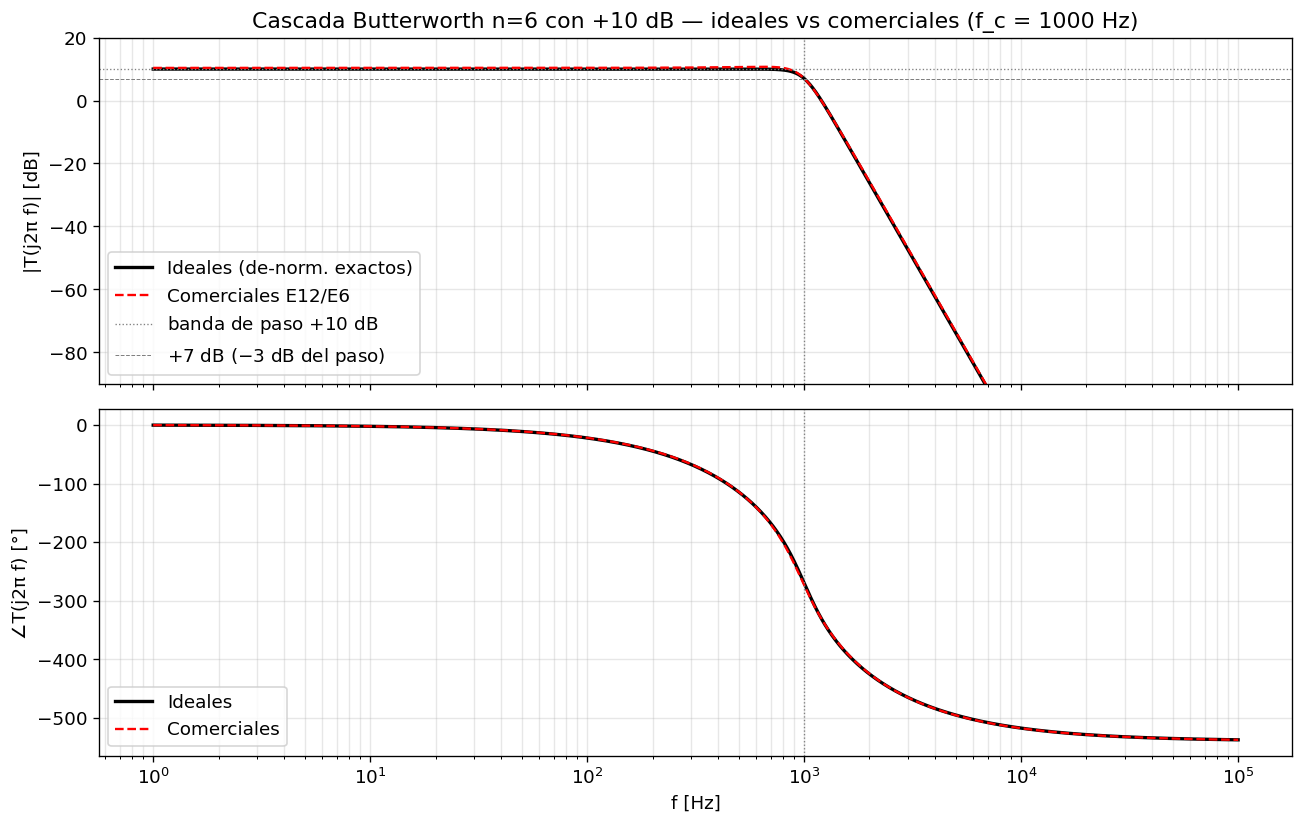

#### Métricas en banda de paso y en f_c

  Gain DC ideal      =  10.000 dB   (objetivo: +10.00 dB)
  Gain DC comercial  =  10.370 dB   (Δ = +0.370 dB)
  |T(j2πfc)| ideal     =   6.986 dB  (objetivo: +6.99 dB)
  |T(j2πfc)| comercial =   7.030 dB  (Δ = +0.044 dB)
  ∠T(j2πfc) ideal      =   89.95°    (objetivo: -270°)
  ∠T(j2πfc) comercial  =   86.46°    (Δ = -3.49°)

  f_-3dB ideal     =   999.5 Hz  (objetivo: 1000 Hz)
  f_-3dB comercial =   987.9 Hz  (Δ = -1.16%)


In [12]:
# ── Bode comparativo: ideales vs comerciales E12/E6 ──
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig
from pytc2.general import print_subtitle

fc4 = 1e3
Ow4 = 2*np.pi*fc4
Oz4 = 10e3

def cascada_real(R_sk, C_sk, R_khn, R6, C_khn, R_mfb, C_mfb):
    # Cascada SK + KHN + MFB con los R, C en valores reales (Punto 4).
    R1, R2 = R_sk
    C1, C2 = C_sk
    T_SK = sig.TransferFunction([1.0],
        [R1*R2*C1*C2, C1*(R1+R2), 1.0])
    R = R_khn; R7 = R
    w0 = 1.0/(R*C_khn)
    Q  = (1.0 + R6/R7)/3.0
    T_KHN = sig.TransferFunction([-w0**2], [1.0, w0/Q, w0**2])
    R1m, R2m, R3m = R_mfb
    C1m, C2m = C_mfb
    a1 = (1/R1m + 1/R2m + 1/R3m)/C1m
    a0 = 1/(C1m*C2m*R1m*R2m)
    T_MFB = sig.TransferFunction([-1.0/(C1m*C2m*R2m*R3m)], [1.0, a1, a0])
    num = np.polymul(np.polymul(T_SK.num, T_KHN.num), T_MFB.num)
    den = np.polymul(np.polymul(T_SK.den, T_KHN.den), T_MFB.den)
    return sig.TransferFunction(num, den)

# Ideales (de-normalizados exactos)
T_ideal = cascada_real(
    R_sk  = (Oz4, Oz4),
    C_sk  = (0.9659/(Ow4*Oz4), 1.0353/(Ow4*Oz4)),
    R_khn = Oz4,
    R6    = 1.1213*Oz4,
    C_khn = 1.0/(Ow4*Oz4),
    R_mfb = (np.sqrt(10)*Oz4, Oz4, Oz4),
    C_mfb = (4.4747/(Ow4*Oz4), 0.0707/(Ow4*Oz4)),
)

# Comerciales E12/E6 single-component
T_real = cascada_real(
    R_sk  = (10e3, 10e3),
    C_sk  = (15e-9, 18e-9),
    R_khn = 10e3,
    R6    = 11e3,
    C_khn = 15e-9,
    R_mfb = (33e3, 10e3, 10e3),
    C_mfb = (68e-9, 1.2e-9),
)

f = np.logspace(0, 5, 2000)
w = 2*np.pi*f
_, mag_id, ph_id = sig.bode(T_ideal, w)
_, mag_re, ph_re = sig.bode(T_real,  w)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), dpi=120, sharex=True)
ax1.semilogx(f, mag_id, 'k-',  lw=2,   label='Ideales (de-norm. exactos)')
ax1.semilogx(f, mag_re, 'r--', lw=1.4, label='Comerciales E12/E6')
ax1.axhline(10, color='gray', ls=':', lw=0.8, label='banda de paso $+10$ dB')
ax1.axhline(7,  color='gray', ls='--', lw=0.6, label='$+7$ dB ($-3$ dB del paso)')
ax1.axvline(fc4, color='gray', ls=':', lw=0.8)
ax1.set_ylabel('|T(j2π f)| [dB]')
ax1.set_title(f'Cascada Butterworth n=6 con +10 dB — ideales vs comerciales (f_c = {fc4:.0f} Hz)')
ax1.grid(True, which='both', alpha=0.3)
ax1.legend(loc='lower left')
ax1.set_ylim(-90, 20)

ax2.semilogx(f, ph_id, 'k-',  lw=2,   label='Ideales')
ax2.semilogx(f, ph_re, 'r--', lw=1.4, label='Comerciales')
ax2.axvline(fc4, color='gray', ls=':', lw=0.8)
ax2.set_xlabel('f [Hz]')
ax2.set_ylabel('∠T(j2π f) [°]')
ax2.grid(True, which='both', alpha=0.3)
ax2.legend(loc='lower left')
plt.tight_layout()
plt.show()

def evalua(T, f_eval):
    w_eval = 2*np.pi*np.atleast_1d(f_eval)
    _, m, ph = sig.bode(T, w_eval)
    return m, ph

m_id_dc, _   = evalua(T_ideal, 1)
m_re_dc, _   = evalua(T_real,  1)
m_id_fc, ph_id_fc = evalua(T_ideal, fc4)
m_re_fc, ph_re_fc = evalua(T_real,  fc4)

print_subtitle('Métricas en banda de paso y en f_c')
print(f'  Gain DC ideal      = {m_id_dc[0]:7.3f} dB   (objetivo: +10.00 dB)')
print(f'  Gain DC comercial  = {m_re_dc[0]:7.3f} dB   (Δ = {m_re_dc[0]-m_id_dc[0]:+.3f} dB)')
print(f'  |T(j2πfc)| ideal     = {m_id_fc[0]:7.3f} dB  (objetivo: +6.99 dB)')
print(f'  |T(j2πfc)| comercial = {m_re_fc[0]:7.3f} dB  (Δ = {m_re_fc[0]-m_id_fc[0]:+.3f} dB)')
print(f'  ∠T(j2πfc) ideal      = {ph_id_fc[0]:7.2f}°    (objetivo: -270°)')
print(f'  ∠T(j2πfc) comercial  = {ph_re_fc[0]:7.2f}°    (Δ = {ph_re_fc[0]-ph_id_fc[0]:+.2f}°)')

def f3db(T, gain_dc_dB):
    fk = np.logspace(np.log10(100), np.log10(20e3), 5000)
    _, m, _ = sig.bode(T, 2*np.pi*fk)
    idx = np.argmin(np.abs(m - (gain_dc_dB - 3.0)))
    return fk[idx]

f3_id = f3db(T_ideal, m_id_dc[0])
f3_re = f3db(T_real,  m_re_dc[0])
print(f'\n  f_-3dB ideal     = {f3_id:7.1f} Hz  (objetivo: 1000 Hz)')
print(f'  f_-3dB comercial = {f3_re:7.1f} Hz  (Δ = {(f3_re-f3_id)/f3_id*100:+.2f}%)')


**Conclusión.** Los redondeos a componentes E12/E6 introducen menos del $1{,}2\%$ de corrimiento en $f_c$ y $0{,}4$ dB en ganancia — un valor tolerable para la mayoria de las aplicaciones. Las dos curvas son visualmente indistinguibles en banda de paso y en la asíntota de descenso; la diferencia más notoria es un pequeño "redoblamiento" del $Q$ del MFB cerca de $f_c$ por el $+6{,}7\%$ en $C_2$ del MFB.

> Si se quisiera quedar más cerca del ideal, el $C_2$ del MFB ($1{,}125$ nF) admite una combinación serie $1{,}5\,\text{nF}\parallel 5{,}6\,\text{nF}$ o usar $1{,}1$ nF E96.

<a id="b1"></a>

---

## Bonus 1 — ¿Se pueden reutilizar las SOS del Butterworth $n=6$ para sintetizar uno de orden $7$?

**Respuesta corta: no.** Aunque al pasar de $n=6$ a $n=7$ aparece un polo real simple sobre el eje $\sigma$ (que sí se podría agregar como sección de primer orden), los **otros seis polos cambian de posición**: sus ángulos respecto del eje real son distintos a los del orden 6, así que los $Q_k$ de las SOS no coinciden y hay que rediseñar cada etapa.

### Razonamiento

Los polos del Butterworth normalizado son las raíces de $|H(j\omega)|^2 = 1/(1+\omega^{2n})$, $2n$ puntos equiespaciados sobre el círculo unitario:

$$s_k = e^{\,j(2k+n-1)\pi/(2n)}, \qquad k = 0,\,1,\,\dots,\,2n-1$$

Esta fórmula enumera **los $2n$ polos completos**. De ellos, $n$ caen en el SPI (los que el filtro estable usa) y $n$ en el SPD (que se descartan: darían un filtro inestable). Como cada par conjugado del SPI define un único $Q$ —y por lo tanto una única SOS— conviene reorganizar los polos del SPI en función del **ángulo $\varphi$ que cada uno forma con el eje real negativo**. Sobre el SPI, los polos quedan separados un ángulo constante

$$\boxed{\;\Delta\varphi = \dfrac{\pi}{n}\;}$$

y la diferencia entre $n$ par e impar está en dónde arranca el primer polo:

- **$n$ par** ($n=2,4,6,\dots$): el primer polo está desplazado medio paso del eje $\sigma$,

  $$\varphi_1 = \frac{\pi}{2n}, \qquad \varphi_k = \frac{\pi}{2n} + (k-1)\frac{\pi}{n}, \qquad k = 1, \dots, \frac{n}{2}$$

  (cada $k$ es un par conjugado del SPI: $n/2$ pares totales).

- **$n$ impar** ($n=3,5,7,\dots$): el primer polo cae exactamente sobre el eje $\sigma$ (polo **real** en $s = -1$, $Q = 1/2$), y los pares conjugados están en

  $$\varphi_k = k\,\frac{\pi}{n}, \qquad k = 1, 2, \dots, \frac{n-1}{2}$$

  ($(n-1)/2$ pares conjugados + 1 polo real).

El Q de cada par conjugado se obtiene como

$$\boxed{\;Q_k = \dfrac{1}{2\cos\varphi_k}\;}$$

#### Aplicado a $n=6$ (par)

$$\varphi_1 = \tfrac{\pi}{12} = 15°,\quad \varphi_2 = \tfrac{\pi}{12} + \tfrac{\pi}{6} = \tfrac{3\pi}{12} = 45°,\quad \varphi_3 = \tfrac{\pi}{12} + 2\tfrac{\pi}{6} = \tfrac{5\pi}{12} = 75°$$

#### Aplicado a $n=7$ (impar)

Polo real en $s = -1$ ($Q = 0{,}5$) más

$$\varphi_1 = \tfrac{\pi}{7} \approx 25{,}7°,\quad \varphi_2 = \tfrac{2\pi}{7} \approx 51{,}4°,\quad \varphi_3 = \tfrac{3\pi}{7} \approx 77{,}1°$$

El **primer par** del orden 7 ($\varphi = \pi/7$) cae mucho más lejos del eje real que el primer par del orden 6 ($\varphi = \pi/12$). Esto se traduce en que la SOS de menor $Q$ del orden 7 tiene $Q = 0{,}555$ en lugar de $0{,}518$ — los componentes calculados en el Punto 3 ya **no realizan** ese par. Lo mismo ocurre con los otros dos pares.

El bloque de código abajo lista los $Q_k$ de los dos órdenes y plotea ambos patrones de polos: las posiciones no se superponen.

#### Comparación Butterworth n=6 vs n=7 (norm., w0=1)

  n=6 (par)   → primer ángulo π/(2n) = π/12,  Δφ = π/6
        φ_k = ['π/12', '3π/12', '5π/12']
        Q_k = [0.5176, 0.7071, 1.9319]

  n=7 (impar) → primer polo en σ (real),       Δφ = π/7
        polo real: s = -1 (Q = 0.5)
        φ_k = ['π/7', '2π/7', '3π/7']   (pares conjugados)
        Q_k = [0.5, 0.555, 0.8019, 2.247]

  Δ Q (par a par): ['+7.2%', '+13.4%', '+16.3%']
  → Las SOS del Punto 3 NO realizan los Q del orden 7.


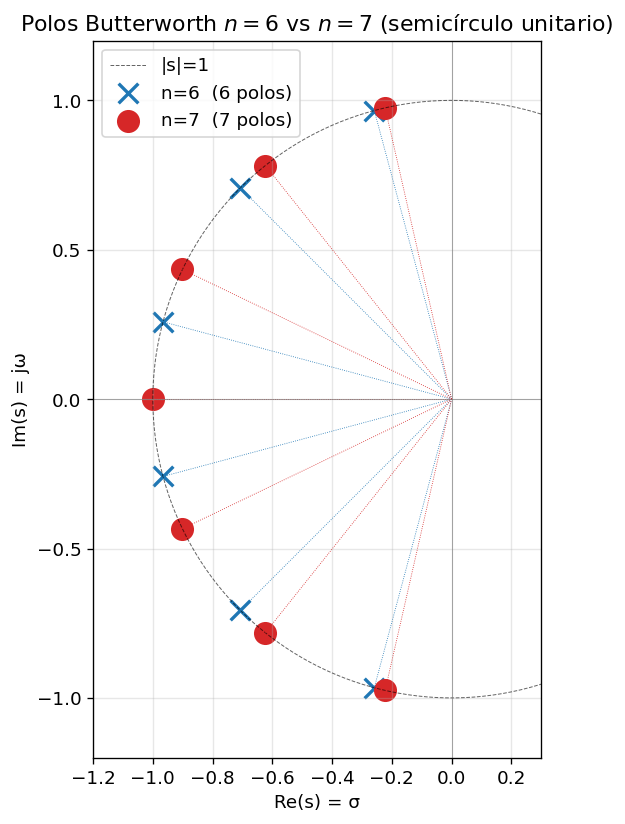

In [13]:
# ── Bonus 1: comparación de polos Butterworth n=6 vs n=7 ──
import numpy as np
import matplotlib.pyplot as plt
from pytc2.general import print_subtitle

def angulos_pares_butter(n):
    # Ángulos de los pares conjugados (medidos desde el eje real negativo)
    # n par   → φ_k = π/(2n) + (k-1)·π/n,   k = 1..n/2
    # n impar → φ_k = k·π/n,                k = 1..(n-1)/2  (más polo real en σ)
    if n % 2 == 0:
        ks = np.arange(1, n//2 + 1)
        return np.pi/(2*n) + (ks - 1)*np.pi/n
    else:
        ks = np.arange(1, (n-1)//2 + 1)
        return ks*np.pi/n

def fmt_phi_pi(n):
    # Devuelve los φ_k expresados como fracciones de π en formato 'aπ/b'.
    if n % 2 == 0:
        # numeradores 1, 3, 5, ..., (n-1) sobre 2n
        nums = [2*k - 1 for k in range(1, n//2 + 1)]
        return [f'{a}π/{2*n}' if a > 1 else f'π/{2*n}' for a in nums]
    else:
        # numeradores 1, 2, ..., (n-1)/2 sobre n
        return [f'{k}π/{n}' if k > 1 else f'π/{n}' for k in range(1, (n-1)//2 + 1)]

def polos_butter(n):
    phis = angulos_pares_butter(n)
    polos = np.concatenate([
        -np.cos(phis) + 1j*np.sin(phis),
        -np.cos(phis) - 1j*np.sin(phis),
    ])
    if n % 2 == 1:
        polos = np.append(polos, -1.0 + 0j)     # polo real
    return polos

def Qs_de(phis, hay_polo_real):
    qs = [1/(2*np.cos(p)) for p in phis]
    if hay_polo_real:
        qs = [0.5] + qs
    return sorted(qs)

phi6 = angulos_pares_butter(6)
phi7 = angulos_pares_butter(7)
P6 = polos_butter(6)
P7 = polos_butter(7)
Q6 = Qs_de(phi6, hay_polo_real=False)
Q7 = Qs_de(phi7, hay_polo_real=True)

print_subtitle('Comparación Butterworth n=6 vs n=7 (norm., w0=1)')
print(f'  n=6 (par)   → primer ángulo π/(2n) = π/12,  Δφ = π/6')
print(f'        φ_k = {fmt_phi_pi(6)}')
print(f'        Q_k = {[float(round(q, 4)) for q in Q6]}')
print(f'\n  n=7 (impar) → primer polo en σ (real),       Δφ = π/7')
print(f'        polo real: s = -1 (Q = 0.5)')
print(f'        φ_k = {fmt_phi_pi(7)}   (pares conjugados)')
print(f'        Q_k = {[float(round(q, 4)) for q in Q7]}')
deltas = [(q7-q6)/q6*100 for q6, q7 in zip(Q6, Q7[1:])]
print(f'\n  Δ Q (par a par): {[f"{d:+.1f}%" for d in deltas]}')
print(f'  → Las SOS del Punto 3 NO realizan los Q del orden 7.')

fig, ax = plt.subplots(figsize=(7, 7), dpi=120)
theta = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(theta), np.sin(theta), 'k--', lw=0.6, alpha=0.6, label='|s|=1')
ax.scatter(P6.real, P6.imag, s=140, marker='x', c='C0', lw=2,   label=f'n=6  ({len(P6)} polos)')
ax.scatter(P7.real, P7.imag, s=140, marker='o', c='C3', lw=2,
           facecolors='none', label=f'n=7  ({len(P7)} polos)')

for phi in phi6:
    ax.plot([0, -np.cos(phi)], [0,  np.sin(phi)], color='C0', lw=0.5, ls=':')
    ax.plot([0, -np.cos(phi)], [0, -np.sin(phi)], color='C0', lw=0.5, ls=':')
for phi in phi7:
    ax.plot([0, -np.cos(phi)], [0,  np.sin(phi)], color='C3', lw=0.5, ls=':')
    ax.plot([0, -np.cos(phi)], [0, -np.sin(phi)], color='C3', lw=0.5, ls=':')
ax.plot([0, -1], [0, 0], color='C3', lw=0.5, ls=':')

ax.axhline(0, color='gray', lw=0.4); ax.axvline(0, color='gray', lw=0.4)
ax.set_xlim(-1.2, 0.3); ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal')
ax.set_xlabel('Re(s) = σ');  ax.set_ylabel('Im(s) = jω')
ax.set_title('Polos Butterworth $n=6$ vs $n=7$ (semicírculo unitario)')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()


**Conclusión.** No se puede *reciclar* los $C$ y $R$ calculados para $n=6$ — los polos del Butterworth de orden 7 caen en otros ángulos del semicírculo unitario, lo que cambia los $Q$ de cada SOS y obliga a rediseñar las tres etapas. Lo único que se "reutiliza" en sentido estricto son las **topologías** y el **patrón de cascada**, más una sección de primer orden adicional para el polo real.

<a id="b2"></a>

---

## Bonus 2 — Diseño de la cascada Butterworth $n=7$

La cascada propuesta (en el mismo orden del LTSpice):

$$V_i \;\to\; \boxed{\text{SK}} \;\xrightarrow{\text{buf}}\; \boxed{\text{KHN}} \;\xrightarrow{\text{buf}}\; \boxed{\text{MFB}} \;\xrightarrow{\text{buf}}\; \boxed{\text{RC}} \;\to\; V_o$$

Ganancia total: $K_{tot} = (+1)(-1)(-1)(+1) = +1$ (0 dB). A continuación el procedimiento manuscrito y su transcripción.

### 2.1 Diagrama de polos y SOS1 (SK)

<div align="center">
<img src="img/b2_hoja_1.jpg" width="650"/>
</div>

#### Ángulos de los polos ($n=7$ impar, $\Delta\varphi = \pi/7$)

| SOS | $\varphi_k$ |
|:--:|:--:|
| Polo real | $0$ (sobre el eje $-\sigma$) |
| SOS1 | $\varphi_1 = \pi/7$ |
| SOS2 | $\varphi_2 = \pi/7 + \pi/7 = 2\pi/7$ |
| SOS3 | $\varphi_3 = 2\pi/7 + \pi/7 = 3\pi/7$ |

#### SOS1 — SK ($K=1$)

$$T_1(s) = \frac{1}{s^2 + 2\cos(\pi/7)\,s + 1} = \frac{1}{s^2 + 1{,}8019\,s + 1}$$

Con $K=1$: $R_4 = 0$, $R_3 \to \infty$ (desconectado). Con $R_1 = R_2 = R = 1$:

$$\omega_0^2 = \frac{1}{R^2 C_1 C_2} = 1 \;\Rightarrow\; C_1 C_2 = 1$$

### 2.2 Componentes de SOS1 y SOS2

<div align="center">
<img src="img/b2_hoja_2.jpg" width="650"/>
</div>

#### SOS1 — SK: despeje de $C_1$, $C_2$

De $C_1 C_2 = 1$ y la expresión del $Q$ del SK (con $R_1=R_2=1$, $K=1$):

$$Q = \frac{\sqrt{C_1 C_2}}{C_1 \cdot 2} = \frac{1}{2}\sqrt{\frac{C_2}{C_1}} \;\Rightarrow\; \frac{C_2}{C_1} = 4Q_1^2$$

Combinando con $C_1 C_2 = 1$:

$$C_1 = \frac{1}{2Q_1} = \cos\!\left(\frac{\pi}{7}\right) \approx 0{,}9009, \qquad C_2 = 2Q_1 = \frac{1}{\cos(\pi/7)} \approx 1{,}1099$$

$$\boxed{R_1=R_2=1\;\Omega,\quad R_4=0,\quad R_3\to\infty,\quad C_1=0{,}9009\;\text{F},\quad C_2=1{,}1099\;\text{F}}$$

#### SOS2 — KHN ($R_{1\dots5}=R_7=C_1=C_2=1$, $K=-1$)

$$T_2(s) = \frac{-1}{s^2 + 2\cos(2\pi/7)\,s + 1} = \frac{-1}{s^2 + 1{,}2470\,s + 1}$$

$$Q_2 = \frac{1}{2\cos(2\pi/7)} \approx 0{,}8019 = \frac{R_6 + R_7}{3R_7} \;\Rightarrow\; R_6 = (3Q_2 - 1)\,R_7 = 1{,}4058\,R_7$$

$$\boxed{R_7 = 1\;\Omega,\quad R_6 = 1{,}4058\;\Omega}$$

### 2.3 SOS3 (MFB), etapa RC y cascada final

<div align="center">
<img src="img/b2_hoja_3.jpg" width="650"/>
</div>

#### SOS3 — MFB ($R_1=R_2=R_3=1$, $K=-1$)

$$T_3(s) = \frac{-1}{s^2 + 2\cos(3\pi/7)\,s + 1} = \frac{-1}{s^2 + 0{,}4450\,s + 1}$$

Con $R_1=R_2=R_3=1$ y $\omega_0=1 \Rightarrow C_1 C_2 = 1$. De la expresión de $Q$ de la MFB:

$$Q = \frac{1}{3}\sqrt{\frac{C_1}{C_2}} \;\Rightarrow\; C_1 = 3Q_3,\quad C_2 = \frac{1}{3Q_3}$$

$$Q_3 = \frac{1}{2\cos(3\pi/7)} \approx 2{,}2470 \;\Rightarrow\; \boxed{C_1 = 6{,}7409\;\text{F},\quad C_2 = 0{,}1483\;\text{F}}$$

#### Etapa RC (polo real en $s=-1$)

Divisor $R$–$C$ con $R$ en serie y $C$ a tierra:

$$\frac{V_o}{V_i} = \frac{Z_C}{Z_R + Z_C} = \frac{1/sC}{R + 1/sC} = \frac{1}{1 + sRC}$$

Con $R=C=1$: $\;\boxed{T_\text{RC}(s) = \dfrac{1}{s+1}}$

#### Transferencia total del Butterworth $n=7$

$$T(s) = \underbrace{\frac{1}{s^2+1{,}8019\,s+1}}_{\text{SK}}\cdot\underbrace{\frac{-1}{s^2+1{,}2470\,s+1}}_{\text{KHN}}\cdot\underbrace{\frac{-1}{s^2+0{,}4450\,s+1}}_{\text{MFB}}\cdot\underbrace{\frac{1}{s+1}}_{\text{RC}}$$

$$= \frac{1}{(s^2+1{,}8019\,s+1)(s^2+1{,}2470\,s+1)(s^2+0{,}4450\,s+1)(s+1)}$$

que es exactamente el Butterworth normalizado de orden 7 con $\omega_0=1$ rad/s.

que, multiplicando todos los factores, se puede escribir también en su forma **no factorizada**:

$$T(s) = \frac{1}{s^7 + 4{,}494\,s^6 + 10{,}098\,s^5 + 14{,}592\,s^4 + 14{,}592\,s^3 + 10{,}098\,s^2 + 4{,}494\,s + 1}$$

In [14]:
# ── Bonus 2 — Verificación numérica de la cascada n=7 ──
import numpy as np
from scipy import signal as sig
from pytc2.general import print_subtitle

# Ángulos y Q (n=7, impar, Δφ=π/7)
n7 = 7
phi7 = np.array([k*np.pi/n7 for k in range(1, (n7-1)//2 + 1)])
Q1, Q2, Q3 = 1/(2*np.cos(phi7))

# Componentes normalizados
C1_sk7, C2_sk7 = 1/(2*Q1), 2*Q1       # SK
R6_khn7 = 3*Q2 - 1                     # KHN
C1_mfb7, C2_mfb7 = 3*Q3, 1/(3*Q3)    # MFB

print_subtitle('Componentes normalizados — Butterworth n=7')
print(f'  φ1=π/7, φ2=2π/7, φ3=3π/7')
print(f'  Q1={Q1:.4f}, Q2={Q2:.4f}, Q3={Q3:.4f}')
print(f'\n  SK  : R1=R2=1 Ω, C1={C1_sk7:.4f} F, C2={C2_sk7:.4f} F')
print(f'  KHN : R1..R5=R7=1 Ω, C1=C2=1 F, R6={R6_khn7:.4f} Ω')
print(f'  MFB : R1=R2=R3=1 Ω, C1={C1_mfb7:.4f} F, C2={C2_mfb7:.4f} F')
print(f'  RC  : R=C=1 (polo real s=-1)')

# Transferencias
T_SK7  = sig.TransferFunction([1.0],  [C1_sk7*C2_sk7, 2*C1_sk7, 1.0])
T_KHN7 = sig.TransferFunction([-1.0], [1.0, 1/Q2, 1.0])
T_MFB7 = sig.TransferFunction([-1.0], [C1_mfb7*C2_mfb7, 3*C2_mfb7, 1.0])
T_RC7  = sig.TransferFunction([1.0],  [1.0, 1.0])

# Cascada (orden: SK → KHN → MFB → RC)
stages = [T_SK7, T_KHN7, T_MFB7, T_RC7]
num, den = stages[0].num, stages[0].den
for T in stages[1:]:
    num = np.polymul(num, T.num)
    den = np.polymul(den, T.den)
num = num/den[0]; den = den/den[0]

# Referencia Butterworth n=7
denref7 = np.array([1.0])
for p in phi7: denref7 = np.polymul(denref7, [1, 2*np.cos(p), 1])
denref7 = np.polymul(denref7, [1, 1])

print_subtitle('Verificación: cascada == Butterworth n=7')
print(f'  den cascada    : {np.round(den, 4)}')
print(f'  den referencia : {np.round(denref7, 4)}')
print(f'  |H(0)|         : {abs(num[-1]):.4f}   (esperado: 1.0000)')
print(f'  ¿Coinciden?      {np.allclose(den, denref7, rtol=1e-3)}')


#### Componentes normalizados — Butterworth n=7

  φ1=π/7, φ2=2π/7, φ3=3π/7
  Q1=0.5550, Q2=0.8019, Q3=2.2470

  SK  : R1=R2=1 Ω, C1=0.9010 F, C2=1.1099 F
  KHN : R1..R5=R7=1 Ω, C1=C2=1 F, R6=1.4058 Ω
  MFB : R1=R2=R3=1 Ω, C1=6.7409 F, C2=0.1483 F
  RC  : R=C=1 (polo real s=-1)


#### Verificación: cascada == Butterworth n=7

  den cascada    : [ 1.      4.494  10.0978 14.5918 14.5918 10.0978  4.494   1.    ]
  den referencia : [ 1.      4.494  10.0978 14.5918 14.5918 10.0978  4.494   1.    ]
  |H(0)|         : 1.0000   (esperado: 1.0000)
  ¿Coinciden?      True


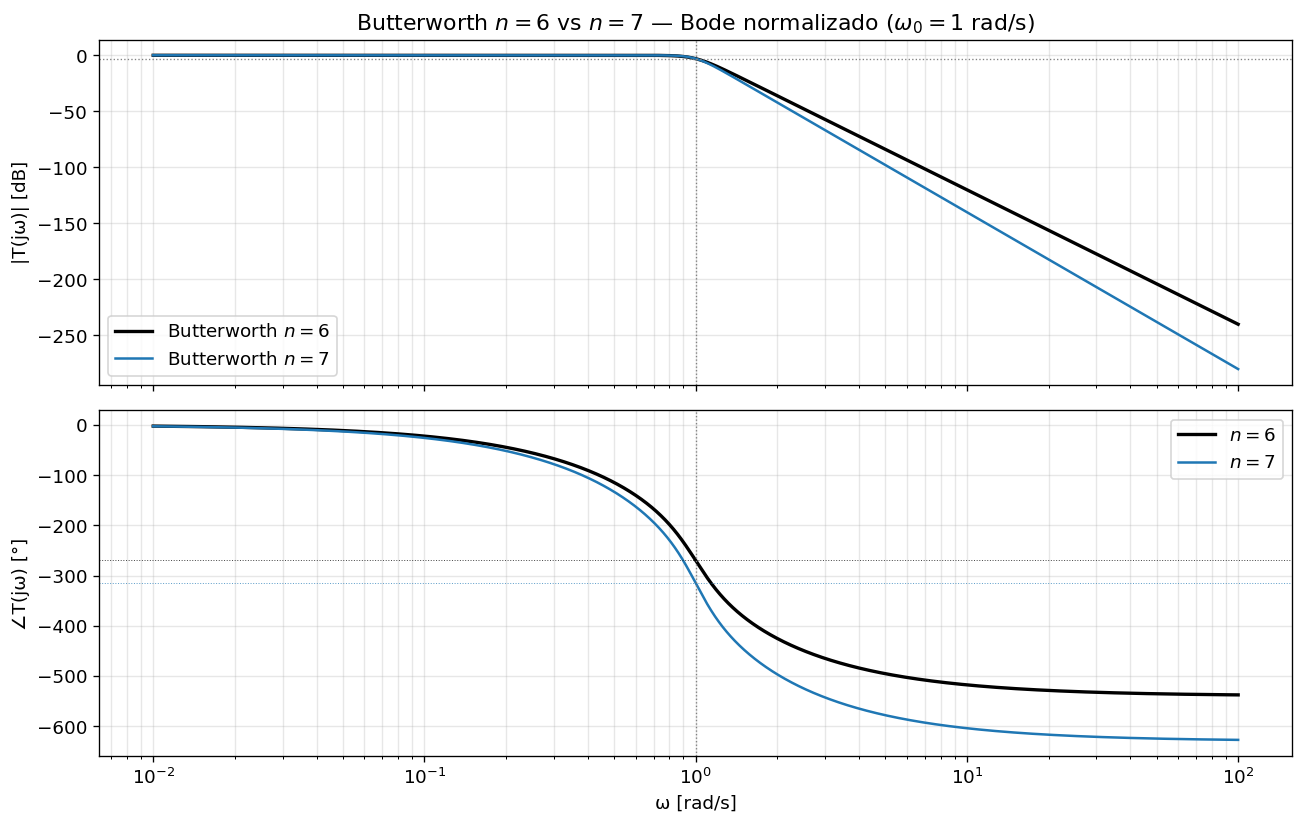

In [15]:
import matplotlib.pyplot as plt
from pytc2.general import print_subtitle

T_cas7 = sig.TransferFunction(num, den)

# Butterworth n=6 para comparar
phi6 = np.array([np.pi/12, 3*np.pi/12, 5*np.pi/12])
den6 = np.array([1.0])
for p in phi6: den6 = np.polymul(den6, [1, 2*np.cos(p), 1])
T_ref6 = sig.TransferFunction([1.0], den6)

w = np.logspace(-2, 2, 3000)
_, mag7, ph7 = sig.bode(T_cas7, w)
_, mag6, ph6 = sig.bode(T_ref6, w)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), dpi=120, sharex=True)

ax1.semilogx(w, mag6, 'k-',  lw=2,   label='Butterworth $n=6$')
ax1.semilogx(w, mag7, 'C0-', lw=1.5, label='Butterworth $n=7$')
ax1.axvline(1, color='gray', ls=':', lw=0.8)
ax1.axhline(-3, color='gray', ls=':', lw=0.8)
ax1.set_ylabel('|T(jω)| [dB]')
ax1.set_title('Butterworth $n=6$ vs $n=7$ — Bode normalizado ($\omega_0=1$ rad/s)')
ax1.grid(True, which='both', alpha=0.3)
ax1.legend()

ax2.semilogx(w, ph6, 'k-',  lw=2,   label='$n=6$')
ax2.semilogx(w, ph7, 'C0-', lw=1.5, label='$n=7$')
ax2.axvline(1, color='gray', ls=':', lw=0.8)
ax2.axhline(-315, color='C0', ls=':', lw=0.6, alpha=0.7)
ax2.axhline(-270, color='k',  ls=':', lw=0.6, alpha=0.7)
ax2.set_xlabel('ω [rad/s]'); ax2.set_ylabel('∠T(jω) [°]')
ax2.grid(True, which='both', alpha=0.3)
ax2.legend()
plt.tight_layout(); plt.show()


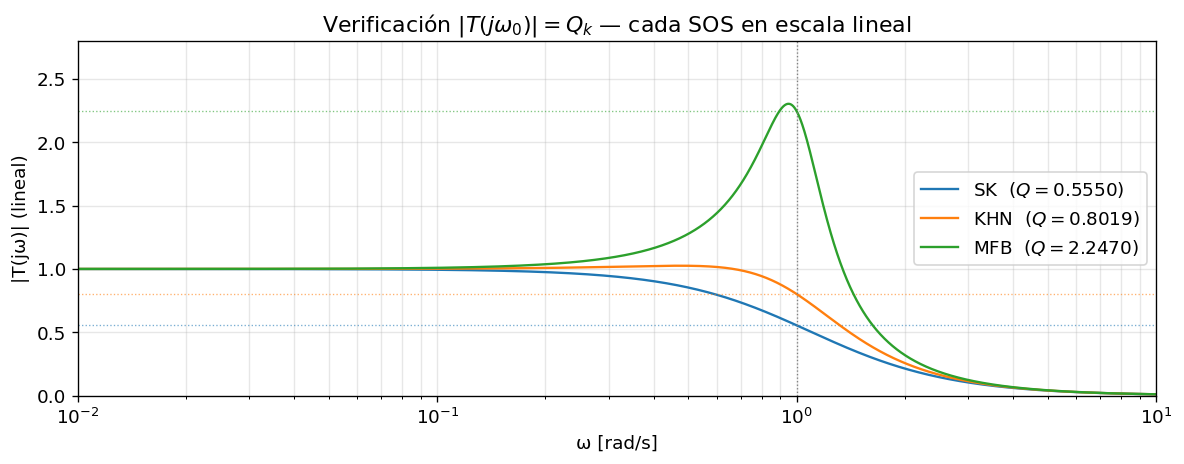

#### |T(jω₀)| por SOS — n=7

  SK  : |T(j1)| = 0.5555   (Q_k = 0.5550)  ✓
  KHN : |T(j1)| = 0.8027   (Q_k = 0.8019)  ✓
  MFB : |T(j1)| = 2.2490   (Q_k = 2.2470)  ✓


In [16]:
# ── Verificación |T(jω0)| = Q_k en escala lineal por etapa ──

w_lin = np.logspace(-3, 2, 5000)
stages_info = [
    ('SK',  T_SK7,  Q1),
    ('KHN', T_KHN7, Q2),
    ('MFB', T_MFB7, Q3),
]

fig, ax = plt.subplots(figsize=(10, 4), dpi=120)
colors = ['C0', 'C1', 'C2']
for (nombre, T, Qk), col in zip(stages_info, colors):
    _, m, _ = sig.bode(T, w_lin)
    m_lin = 10**(m/20)
    ax.semilogx(w_lin, m_lin, color=col, lw=1.4, label=f'{nombre}  ($Q={Qk:.4f}$)')
    ax.axhline(Qk, color=col, ls=':', lw=0.8, alpha=0.6)

ax.axvline(1, color='gray', ls=':', lw=0.8)
ax.set_xlim(1e-2, 10); ax.set_ylim(0, 2.8)
ax.set_xlabel('ω [rad/s]'); ax.set_ylabel('|T(jω)| (lineal)')
ax.set_title('Verificación $|T(j\omega_0)| = Q_k$ — cada SOS en escala lineal')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout(); plt.show()

print_subtitle('|T(jω₀)| por SOS — n=7')
w0_i = np.argmin(np.abs(w_lin - 1))
for nombre, T, Qk in stages_info:
    _, m, _ = sig.bode(T, w_lin)
    m_lin = 10**(m/20)
    print(f'  {nombre:4s}: |T(j1)| = {m_lin[w0_i]:.4f}   (Q_k = {Qk:.4f})  '
          f'{"✓" if abs(m_lin[w0_i]-Qk)<0.005 else "✗"}')


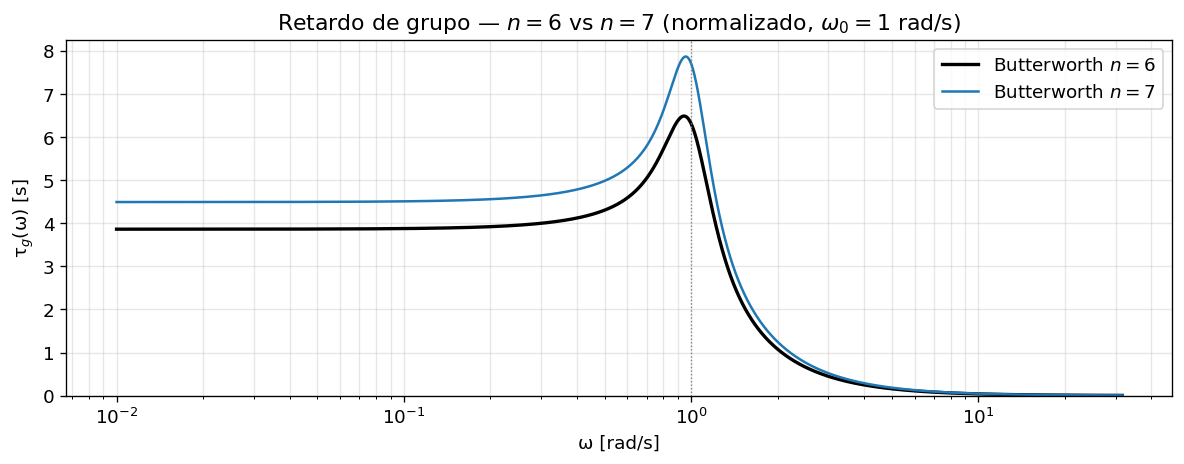

#### Retardo de grupo — comparación n=6 vs n=7

  τ_g(0)  n=6 ≈ 3.864 s   (≈ 1/Q1 + 1/Q2 + 1/Q3 = 3.864 s)
  τ_g(0)  n=7 ≈ 4.494 s   (≈ 1/Q1 + 1/Q2 + 1/Q3 + 1 = 4.494 s)
  τ_g(ω0) n=6 ≈ 6.308 s   (≈ 2Q1+2Q2+2Q3 = 6.313 s)
  τ_g(ω0) n=7 ≈ 7.702 s   (≈ 2Q1+2Q2+2Q3+1/2 = 7.708 s)
  Mayor orden → mayor retardo en DC y mayor distorsión de la envolvente.


In [17]:
# ── Retardo de grupo — comparación n=6 vs n=7 ──
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt
from pytc2.general import print_subtitle

w_gd = np.logspace(-2, 1.5, 3000)   # mismo rango que la celda anterior

# Reconstruye n=6 (mismo código que gd_code6)
phi6g = np.array([np.pi/12, 3*np.pi/12, 5*np.pi/12])
Q1g, Q2g, Q3g = 1/(2*np.cos(phi6g))
C1s6, C2s6 = 1/(2*Q1g), 2*Q1g
C1m6, C2m6 = 3*Q3g, 1/(3*Q3g)
Tsk6  = sig.TransferFunction([1.0],  [C1s6*C2s6, 2*C1s6, 1.0])
Tkhn6 = sig.TransferFunction([-1.0], [1.0, 1/Q2g, 1.0])
Tmfb6 = sig.TransferFunction([-1.0], [C1m6*C2m6, 3*C2m6, 1.0])
tau6  = (group_delay_ct(Tsk6, w_gd) +
         group_delay_ct(Tkhn6, w_gd) +
         group_delay_ct(Tmfb6, w_gd))

# n=7 componentes
phi7g = np.array([k*np.pi/7 for k in range(1, 4)])
Qa, Qb, Qc = 1/(2*np.cos(phi7g))
C1a, C2a = 1/(2*Qa), 2*Qa
C1c, C2c = 3*Qc,    1/(3*Qc)
Tsk7  = sig.TransferFunction([1.0],  [C1a*C2a, 2*C1a, 1.0])
Tkhn7 = sig.TransferFunction([-1.0], [1.0, 1/Qb, 1.0])
Tmfb7 = sig.TransferFunction([-1.0], [C1c*C2c, 3*C2c, 1.0])
Trc7  = sig.TransferFunction([1.0],  [1.0, 1.0])
tau7  = (group_delay_ct(Tsk7,  w_gd) +
         group_delay_ct(Tkhn7, w_gd) +
         group_delay_ct(Tmfb7, w_gd) +
         group_delay_ct(Trc7,  w_gd))

fig, ax = plt.subplots(figsize=(10, 4), dpi=120)
ax.semilogx(w_gd, tau6, 'k-',  lw=2,   label='Butterworth $n=6$')
ax.semilogx(w_gd, tau7, 'C0-', lw=1.5, label='Butterworth $n=7$')
ax.axvline(1, color='gray', ls=':', lw=0.8)
ax.set_xlabel('ω [rad/s]'); ax.set_ylabel('τ$_g$(ω) [s]')
ax.set_title('Retardo de grupo — $n=6$ vs $n=7$ (normalizado, $\omega_0=1$ rad/s)')
ax.set_ylim(0, None); ax.grid(True, which='both', alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

w0_i = np.argmin(np.abs(w_gd - 1))
dc_i = np.argmin(np.abs(w_gd - 0.01))
print_subtitle('Retardo de grupo — comparación n=6 vs n=7')
print(f'  τ_g(0)  n=6 ≈ {tau6[dc_i]:.3f} s   (≈ 1/Q1 + 1/Q2 + 1/Q3 = {1/Q1g+1/Q2g+1/Q3g:.3f} s)')
print(f'  τ_g(0)  n=7 ≈ {tau7[dc_i]:.3f} s   (≈ 1/Q1 + 1/Q2 + 1/Q3 + 1 = {1/Qa+1/Qb+1/Qc+1:.3f} s)')
print(f'  τ_g(ω0) n=6 ≈ {tau6[w0_i]:.3f} s   (≈ 2Q1+2Q2+2Q3 = {2*Q1g+2*Q2g+2*Q3g:.3f} s)')
print(f'  τ_g(ω0) n=7 ≈ {tau7[w0_i]:.3f} s   (≈ 2Q1+2Q2+2Q3+1/2 = {2*Qa+2*Qb+2*Qc+0.5:.3f} s)')
print(f'  Mayor orden → mayor retardo en DC y mayor distorsión de la envolvente.')


<a id="b3"></a>

---

## Bonus 3 — Verificación en LTSpice

Se simula la cascada SK → KHN → MFB → RC con los valores normalizados del Bonus 2 y se verifican las propiedades del Butterworth $n=7$.

### 1) Esquema completo simulado

<div align="center">
<img src="img/b3_lt_circuito.jpg" width="950"/>
</div>

Cuatro bloques punteados, de izquierda a derecha:

- **SOS1 = SK**: `R1_sk=R2_sk=1`, `C1_sk=0.9009`, `C2_sk=1.1099`, `R3_sk=100Meg` (desconectado), `R4_sk=0`. Buffer `U2`.
- **SOS2 = KHN**: `R1_khn…R5_khn=R7_khn=1`, `C1_khn=C2_khn=1`, `R6_khn=1.4058`. Buffer `U6`.
- **SOS3 = MFB**: `R1_mfb=R2_mfb=R3_mfb=1`, `C1_mfb=6.7409`, `C2_mfb=0.1483`. Buffer `U8`.
- **RC**: `R_rc=1`, `C_rc=1`. Polo real en $s=-1$.

Directiva: `.ac dec 1000 0.0001 100`, `.lib opamp.sub`.

### 2) Bode de la cascada total — medición de banda de paso y $f_c$

**Banda de paso plana ($f \ll f_c$):**

<div align="center">
<img src="img/b3_lt_dc.jpg" width="950"/>
</div>

Cursor a $f = 197{,}91\;\mu\text{Hz}$ (DC puro): $|H| = -1{,}09\;\text{mdB} \approx 0\;\text{dB}$ ✓, fase $\approx 0°$. La cascada arranca en $0$ dB como se diseñó ($K_{tot}=+1$).

**Frecuencia de corte $f_c = \omega_0/(2\pi) \approx 159{,}15\;\text{mHz}$:**

<div align="center">
<img src="img/b3_lt_fc.jpg" width="950"/>
</div>

Cursor a $f = 153{,}85\;\text{mHz} \approx f_c$: $|H| = -3{,}14\;\text{dB} \approx -3\;\text{dB}$ ✓, fase $= -316{,}9° \approx -315°$ ✓. Confirma la propiedad definitoria del Butterworth ($|H(j\omega_0)| = 1/\sqrt{2}$) y la fase media del recorrido total ($-315° = n \cdot 45° = 7 \cdot 45°$).

### 3) Pendiente asintótica $-140\;\text{dB/dec}$

<div align="center">
<img src="img/b3_lt_pend.jpg" width="950"/>
</div>

Con los dos cursores: Cursor 1 a $1{,}00\;\text{Hz}$, Mag $= -111{,}82\;\text{dB}$; Cursor 2 a $9{,}98\;\text{Hz}$, Mag $= -251{,}99\;\text{dB}$. Ratio: $-140{,}17\;\text{dB/dec}$ ✓ ($= 7 \times 20\;\text{dB/dec}$, asíntota de orden 7).

### 4) Todas las SOS superpuestas en dB

<div align="center">
<img src="img/b3_lt_bode_sos.jpg" width="950"/>
</div>

Cuatro trazas superpuestas sobre fondo oscuro: todas arrancan planas en $0$ dB en la banda de paso y divergen pasado $\omega_0 \approx 159\;\text{mHz}$. La traza verde cae con la mayor pendiente ($-140\;\text{dB/dec}$, cascada total $V(vo)/V(vin)$); las trazas roja, azul y cyan corresponden a las tres SOS individuales (SK, KHN LPF y MFB) cada una con $-40\;\text{dB/dec}$. El leve pico cercano a $\omega_0$ en la traza de la MFB refleja su $Q_3 \approx 2{,}25$ (el más alto de las tres etapas).

### 5) Verificación $|T(j\omega_0)| = Q_k$ en escala lineal

**SOS1 — SK** (esperado $Q_1 = 1/(2\cos(\pi/7)) \approx 0{,}5550$):

<div align="center">
<img src="img/b3_lt_q_sk.jpg" width="900"/>
</div>

Cursor a $f_0 = 159{,}22\;\text{mHz}$: Mag $= 554{,}75\;\text{m} \approx 0{,}5550$ ✓. Fase $= -90°$ (mitad del recorrido $-180°$ de una SOS no inversora).

**SOS2 — KHN** (esperado $Q_2 = 1/(2\cos(2\pi/7)) \approx 0{,}8019$):

<div align="center">
<img src="img/b3_lt_q_khn.jpg" width="900"/>
</div>

Cursor a $f_0 = 159{,}22\;\text{mHz}$: Mag $= 801{,}55\;\text{m} \approx 0{,}8019$ ✓. Fase $= +89{,}95°$ (inversor: $-180°$ base $+90°$ del desplazamiento $= -90°$ neto, leído como $+90°$).

**SOS3 — MFB** (esperado $Q_3 = 1/(2\cos(3\pi/7)) \approx 2{,}2470$):

<div align="center">
<img src="img/b3_lt_q_mfb.jpg" width="900"/>
</div>

Cursor a $f_0 = 159{,}22\;\text{mHz}$: Mag $= 2{,}2460 \approx 2{,}247$ ✓. Pico pronunciado propio del $Q$ alto de la MFB.

### 6) Tabla resumen de la verificación LTSpice

| Magnitud | Predicho (Bonus 2) | Medido en LTSpice | ✓ |
|:---|:---:|:---:|:---:|
| Ganancia DC ($K_{tot}$) | $0\;\text{dB}$ | $\approx 0\;\text{dB}$ | ✓ |
| $\|H(j\omega_0)\|$ | $-3{,}01\;\text{dB}$ | $-3{,}14\;\text{dB}$ | ✓ |
| Fase en $\omega_0$ | $-315°$ | $-316{,}9°$ | ✓ |
| Pendiente asintótica | $-140\;\text{dB/dec}$ | $-140{,}2\;\text{dB/dec}$ | ✓ |
| $\|T_\text{SK}(j\omega_0)\|$ | $Q_1=0{,}5550$ | $0{,}5548$ | ✓ |
| $\|T_\text{KHN}(j\omega_0)\|$ | $Q_2=0{,}8019$ | $0{,}8016$ | ✓ |
| $\|T_\text{MFB}(j\omega_0)\|$ | $Q_3=2{,}2470$ | $2{,}2460$ | ✓ |

La cascada normalizada reproduce íntegramente las características teóricas del Butterworth $n=7$.

---

#### Conclusión — comparación analítica vs simulación (n=7)

Al igual que en el $n=6$, las desviaciones entre teoría y LTSpice son menores al $1\%$:

- **Módulo en $\omega_0$** por SOS: error $< 0{,}1\%$ para SK y KHN; $0{,}04\%$ para la MFB.
- **Frecuencia de corte**: la atenuación $-3\;\text{dB}$ se verifica a $f_c \approx 159\;\text{mHz}$ ✓.
- **Fase en $\omega_0$**: $-316{,}9°$ vs $-315°$ teórico — diferencia de $1{,}9°$ sobre $630°$.
- **Pendiente**: $-140{,}2$ dB/dec vs $-140$ dB/dec — error $< 0{,}2\%$.

El diseño del Butterworth $n=7$ con la cascada SK + KHN + MFB + RC queda validado tanto analítica como numéricamente.